<a href="https://colab.research.google.com/github/lipikamallikarjuna-gif/Mallikarjuna-et-al-2026/blob/main/LOS_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# Install R and connect to be able to use R magic cells

In [ ]:
!pip uninstall rpy2 -y
!pip install rpy2==3.5.1

Found existing installation: rpy2 3.5.17
Uninstalling rpy2-3.5.17:
  Successfully uninstalled rpy2-3.5.17
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.7/201.7 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for rpy2: filename=rpy2-3.5.1-cp312-cp312-linux_x86_64.whl size=316573 sha256=15aa5a4c82b69c9aae18809b780d165a22f8d9962c564a633c53361be9ede406
  Stored in directory: /root/.cache/pip/wheels/00/26/d5/d5e8c0b039915e785be870270e4a9263e5058168a03513d8cc
Successfully built rpy2


In [ ]:
%load_ext rpy2.ipython

From now on you can use the %%R in front of your code to use R in Colab.

*   Make a link to the folder where to store the R libraries.
*   Next a list of libraries is created which are needed for this project.
*   R libraries will be installed when missing. This can take some time initially but becomes quicker after initial install.

In [ ]:
%%R

.libPaths("/content/drive/Shareddrives/Bovi-Analytics/B&B 2025 Spring semester/R-lib/")

#Packages
packages <- c(
  "readr","ggplot2","dplyr","tidyr","openxlsx",
  "data.table","lubridate","skimr","fuzzyjoin",
  "readxl","knitr","stringr","broom","glmnet",
  "caret","pROC","brglm2","rpart","rpart.plot",
  "logistf", "precrec"
)

#Install only missing packages
installed_in_custom_lib <- installed.packages(lib = .libPaths()[1])[, "Package"]
new_packages <- packages[!(packages %in% installed_in_custom_lib)]

if(length(new_packages) > 0){
  install.packages(new_packages, repos = "https://cloud.r-project.org", lib = .libPaths()[1], dependencies = TRUE) # Specify lib for installation
}

#Load all packages
invisible(lapply(packages, library, character.only = TRUE))

cat("ALL PACKAGES INSTALLED + LOADED\n")

messages

Attaching package: ‘dplyr’



    filter, lag



    intersect, setdiff, setequal, union



Attaching package: ‘data.table’



    between, first, last



    %notin%


Attaching package: ‘lubridate’



    hour, isoweek, isoyear, mday, minute, month, quarter, second, wday,
    week, yday, year



    date, intersect, setdiff, union



Attaching package: ‘Matrix’



    expand, pack, unpack





Attaching package: ‘pROC’



    cov, smooth, var


  method               from    
  as.character.formula openxlsx

Attaching package: ‘precrec’



    auc




ALL PACKAGES INSTALLED + LOADED


# Import the data



## Calf-donor IDs


In [ ]:
%%R
# Load the data for calf-donor IDs
df_raw_calf_donor_IDs <- readr::read_csv(
    file = '/content/drive/Shareddrives/Bovi-Analytics/B&B 2025 Spring semester/raw_data/calfid_rid.CSV')
glimpse(df_raw_calf_donor_IDs)

New names:
• `` -> `...5`
Rows: 6223 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): ID, BDAT, RDAM
dbl (1): DID
lgl (1): ...5

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 6,223
Columns: 5
$ ID   <chr> "895", "1111", "1220", "1292", "1365", "1383", "1387", "1389", "1…
$ DID  <dbl> 0, 0, 0, 23719, 23719, 24222, 6288, 24548, 24090, 24090, 24135, 2…
$ BDAT <chr> "04/10/18", "10/21/19", "07/30/23", "06/06/23", "10/15/23", "10/2…
$ RDAM <chr> "0", "0", "0", "024057", "024461", "024446", "024476", "023423", …
$ ...5 <lgl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, N…


In [ ]:
%%R
# Fix formatting
df_calf_damIDs <- df_raw_calf_donor_IDs %>%
  dplyr::rename(
      calf_ID = 1,
      recipient_ID = RDAM,
      recipient_calving_date = BDAT,
      dam_ID = DID) %>%
    dplyr::mutate(
        recipient_calving_date = as.Date(recipient_calving_date, format = "%m/%d/%y"),
        calf_ID = as.character(calf_ID),
        recipient_ID = as.character(recipient_ID),
         # REMOVE leading zeros
        calf_ID = sub("^0+", "", calf_ID),
        recipient_ID = sub("^0+", "", recipient_ID)
        )
    df_calf_damIDs <- df_calf_damIDs %>%
  dplyr::select(calf_ID, recipient_ID, recipient_calving_date, dam_ID)
glimpse(df_calf_damIDs)

Rows: 6,223
Columns: 4
$ calf_ID                <chr> "895", "1111", "1220", "1292", "1365", "1383", …
$ recipient_ID           <chr> "", "", "", "24057", "24461", "24446", "24476",…
$ recipient_calving_date <date> 2018-04-10, 2019-10-21, 2023-07-30, 2023-06-06…
$ dam_ID                 <dbl> 0, 0, 0, 23719, 23719, 24222, 6288, 24548, 2409…


## Navel treatment data

In [ ]:
%%R
#Load dataset
df_raw_navel_treatements <- readr::read_csv(
    file = '/content/drive/Shareddrives/Bovi-Analytics/B&B 2025 Spring semester/farm_navel_treatments.csv')
glimpse(df_raw_navel_treatements)

Rows: 116 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): Event, Date, Remark
dbl (2): ID, DIM
lgl (2): Protocols, Technician

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 116
Columns: 7
$ ID         <dbl> 1501, 1506, 1508, 1510, 1537, 1540, 1564, 1565, 1565, 1565,…
$ Event      <chr> "NAVEL", "NAVEL", "NAVEL", "NAVEL", "NAVEL", "NAVEL", "NAVE…
$ DIM        <dbl> 13, 7, 6, 5, 16, 14, 24, 0, 0, 7, 7, 19, 20, 18, 14, 316, 1…
$ Date       <chr> "8/15/2024", "8/15/2024", "8/15/2024", "8/15/2024", "10/1/2…
$ Remark     <chr> "PENICILI", "PENICILI", "PENICILI", "PENICILI", "PENICILI",…
$ Protocols  <lgl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA,…
$ Technician <lgl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA,…


In [ ]:
%%R
#Format dataset
df_navel_treatments <- df_raw_navel_treatements %>%
  dplyr::rename(
      calf_ID = ID, #Change all column names
      navel_treatment_date = Date,
      navel_treatment_type = Remark,
      calf_age = DIM
      ) %>%
    dplyr::mutate(
        navel_treatment_date = as.Date(navel_treatment_date, format = "%m/%d/%Y"),
        navel_indicator = TRUE,
        calf_ID = as.character(calf_ID), #Fix datetimes and column formatting
        recipient_calving_date= navel_treatment_date - calf_age
    ) %>%
    dplyr::select(calf_ID,navel_indicator,recipient_calving_date)%>%
    dplyr::distinct()
    #Remove duplicates
glimpse(df_navel_treatments)

Rows: 81
Columns: 3
$ calf_ID                <chr> "1501", "1506", "1508", "1510", "1537", "1540",…
$ navel_indicator        <lgl> TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE,…
$ recipient_calving_date <date> 2024-08-02, 2024-08-08, 2024-08-09, 2024-08-10…


Check if navel treatments are made unique so always 1 calf is selected

## Recipient records

In [ ]:
%%R
#Load the data for recipient birthdates
df_raw_recipient_birthdates <- readr::read_csv(
    file = '/content/drive/Shareddrives/Bovi-Analytics/B&B 2025 Spring semester/raw_data/farm_recipient_birthdates.csv'
    )
glimpse(df_raw_recipient_birthdates)


Rows: 4173 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): ID, BDAT

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 4,173
Columns: 2
$ ID   <chr> "1220", "1467", "1477", "1489", "1492", "1498", "1506", "1510", "…
$ BDAT <chr> "7/30/2023", "5/11/2024", "5/20/2024", "5/26/2024", "5/29/2024", …


In [ ]:
%%R
#Rename and format cols correctly for birthdates
df_recipient_birthdates <- df_raw_recipient_birthdates %>%
  dplyr::rename( #Rename cols so that we can use recip ID as keys
      recipient_ID = ID,
      recipient_birthdate = BDAT
      ) %>%
  dplyr::mutate( #Reformat birthdate column to date
      recipient_birthdate = as.Date(recipient_birthdate, format = "%m/%d/%Y")
  )
  glimpse(df_recipient_birthdates)

Rows: 4,173
Columns: 2
$ recipient_ID        <chr> "1220", "1467", "1477", "1489", "1492", "1498", "1…
$ recipient_birthdate <date> 2023-07-30, 2024-05-11, 2024-05-20, 2024-05-26, 2…


In [ ]:
%%R #Load in recipient dam records
#Change col types so data is formatted correctly
df_raw_recipient_records <- readr::read_csv(
    file = '/content/drive/Shareddrives/Bovi-Analytics/B&B 2025 Spring semester/raw_data/farm_calving_records_recipients.csv',
    col_types = readr::cols(
          ID = readr::col_character(),
          Date = readr::col_character(),
          Remark = readr::col_character(),
          DIM = readr::col_character()
          )
      )
glimpse(df_raw_recipient_records)

Rows: 6,685
Columns: 7
$ ID         <chr> NA, "874", "895", "895", "1111", "1111", "1665", "1665", "1…
$ Event      <chr> NA, "FRESH", "FRESH", "FRESH", "FRESH", "FRESH", "FRESH", "…
$ DIM        <chr> NA, "0", "0", "0", "0", "0", "0", "0", "0", "0", "0", "0", …
$ Date       <chr> NA, "3/1/2023", "2/14/2023", "4/11/2024", "10/26/2023", "8/…
$ Remark     <chr> NA, "F", "MANGUS", "FANGUS", "F", "TRIPLETS", "F", "M", "F-…
$ Protocols  <lgl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA,…
$ Technician <lgl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA,…


1.Farm_calving_records_recipients could be used to confirm the embryos
(F/M) are embryos

2.ID here is recipient ID and not calf ID

In [ ]:
%%R
 #Rename cols so that we can use them as keys
 #Select relevant columns - we only need id, calving date, calf gender
 #Format dates correctly
df_recipient_records <- df_raw_recipient_records %>%
  dplyr::rename(
      recipient_ID = ID,
      recipient_calving_date = Date,
      calf_gender_remark = Remark) %>%
  dplyr::select(
      recipient_ID,
      recipient_calving_date,
      calf_gender_remark) %>%
  dplyr::mutate(
      recipient_calving_date = as.Date(recipient_calving_date, format = "%m/%d/%Y")
      )
glimpse(df_recipient_records)

Rows: 6,685
Columns: 3
$ recipient_ID           <chr> NA, "874", "895", "895", "1111", "1111", "1665"…
$ recipient_calving_date <date> NA, 2023-03-01, 2023-02-14, 2024-04-11, 2023-1…
$ calf_gender_remark     <chr> NA, "F", "MANGUS", "FANGUS", "F", "TRIPLETS", "…


## Embryo transfer

You need


*   Read each sheet seperately
*   Apply naming convention to each sheet
*   Add identifier to each dataframe reflecting sheet where it comes from
*   Select exactly the same columns in each sheet
*   Union all into 1 dataframe



In [ ]:
%%R

# For-loop to read each sheet of the excel file into a seperate data frame (code from Stack Overflow)
embryos_file_path <- "/content/drive/Shareddrives/Bovi-Analytics/B&B 2025 Spring semester/raw_data/farm_frozen_embryo_transfers2017.xlsx"
embryos_sheets <- getSheetNames(embryos_file_path)
for (sheet_name in embryos_sheets) {
  assign(sheet_name, read.xlsx(embryos_file_path, sheet = sheet_name))
}

In [ ]:
%%R
# Check the name of the sheets
embryos_sheets

#Check that each sheet have been converted to df
class(`Boviteq`)
class(`OakwoodSemex`) # Backticks to prevent space from creating an error
class(`TransOva`)
class(`OakwoodTransfers`)


[1] "data.frame"


In [ ]:
%%R
# Change df names to relevant naming convention
boviteq <- Boviteq
oakwood_semex <- `OakwoodSemex`
transova <- TransOva
oakwood_transfers <- `OakwoodTransfers`

In [ ]:
#Rename the columns
%%R
boviteq_renamed_select <- Boviteq %>%
  dplyr::rename(
      recipient_ID = Recip,
      recipient_bred_date = `Bred.Date`,
      embryo_transfer_date = `Trans.Date`,
      recipient_heat_date = `Heat.Date`,
      recipient_heat_time = `Heat.Time`,
      transfer_day_of_week = `Transfer.Date`,
      recipient_cycle_day = `Recip.Day`,
      sire_ID = Sire,
      donor_ID = Donor,
      embryo_age = Stage,
      embryo_grade = Grade,
      preg_open_status = `Preg/Open`,
      preg_open_binary = `1.=.Preg`,
      calf_GTPI = GTPI) %>%
  dplyr::select(
      recipient_ID,
      recipient_bred_date,
      embryo_transfer_date,
      recipient_heat_date,
      recipient_heat_time,
      recipient_cycle_day,
      sire_ID,
      transfer_day_of_week,
      donor_ID,
      embryo_age,
      embryo_grade,
      preg_open_status,
      preg_open_binary) %>%
  dplyr::mutate( #Change to correct data types and reformat dates
      recipient_ID = as.character(recipient_ID),
      sire_ID = as.factor(sire_ID),
      donor_ID = as.factor(donor_ID),
      embryo_age = as.factor(embryo_age),
      embryo_grade = as.factor(embryo_grade),
      embryo_transfer_date = as.Date(as.numeric(embryo_transfer_date), origin = "1899-12-30"),
      recipient_bred_date = as.Date(as.numeric(recipient_bred_date), origin = "1899-12-30"),
      recipient_heat_time = as.numeric(recipient_heat_time),
      recipient_cycle_day = as.numeric(recipient_cycle_day),
      preg_open_binary = as.numeric(preg_open_binary),
      lab = "boviteq"           )
  # We cannot include calf GTPI because it's not included in all of the datasets.
  glimpse(boviteq_renamed_select)
  colnames(transova)

Rows: 7,781
Columns: 14
$ recipient_ID         <chr> NA, "19275", "19271", "19261", "19232", "19202", …
$ recipient_bred_date  <date> NA, 2018-09-04, 2018-08-28, 2018-08-28, 2018-08-…
$ embryo_transfer_date <date> NA, 2018-09-11, 2018-09-04, 2018-09-04, 2018-09-…
$ recipient_heat_date  <chr> NA, "MON", "MON", "MON", "FRI", "MON", "MON", "TH…
$ recipient_heat_time  <dbl> NA, 0.25000000, 0.33333333, 0.83333333, 0.0833333…
$ recipient_cycle_day  <dbl> NA, 8.0, 8.0, 7.5, 8.0, 8.0, 8.0, 8.0, 7.0, 7.5, …
$ sire_ID              <fct> NA, EINSTEIN, EINSTEIN, EINSTEIN, EINSTEIN, EINST…
$ transfer_day_of_week <chr> NA, "TUES", "TUES", "TUES", "FRI", "TUES", "TUES"…
$ donor_ID             <fct> NA, 18382/18596, 18382/18596, 18382/18596, 18382/…
$ embryo_age           <fct> NA, 4, 5, 5, 4, 4, 4, 5, 5, 5, 4, 7, 8, 5, 7, 7, …
$ embryo_grade         <fct> NA, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, …
$ preg_open_status     <chr> NA, "PREG", "OPEN", "PREG", "OPEN", "PREG", "PREG…
$ preg_open_bina

In [ ]:
#Repeat for the other dfs
%%R
oakwood_semex_renamed_select <- oakwood_semex %>%
  dplyr::rename(
      recipient_ID = Recip,
      recipient_bred_date = `Bred.Date`,
      embryo_transfer_date = `Trans.Date`,
      recipient_heat_date = `Heat.Date`,
      recipient_heat_time = `Heat.Time`,
      transfer_day_of_week = `Transfer.Date`,
      recipient_cycle_day = `Recip.Day`,
      sire_ID = Sire,
      donor_ID = Donor,
      embryo_age = Stage,
      embryo_grade = Grade,
      preg_open_status = `Preg/Open`,
      preg_open_binary = `1.=.Preg`) %>%
  dplyr::select(
      recipient_ID,
      recipient_bred_date,
      embryo_transfer_date,
      recipient_heat_date,
      recipient_heat_time,
      recipient_cycle_day,
      sire_ID,
      transfer_day_of_week,
      donor_ID,
      embryo_age,
      embryo_grade,
      preg_open_status,
      preg_open_binary) %>%
  dplyr::mutate( #Change to correct data types and reformat dates
      recipient_ID = as.character(recipient_ID),
      sire_ID = as.factor(sire_ID),
      donor_ID = as.factor(donor_ID),
      embryo_age = as.factor(embryo_age),
      embryo_grade = as.factor(embryo_grade),
      embryo_transfer_date = as.Date(as.numeric(embryo_transfer_date), origin = "1899-12-30"),
      recipient_bred_date = as.Date(as.numeric(recipient_bred_date), origin = "1899-12-30"),
      recipient_heat_time = as.numeric(recipient_heat_time),
      lab = "oakwood_semex"
                 )
  glimpse(oakwood_semex_renamed_select)
  colnames(oakwood_transfers)

Rows: 322
Columns: 14
$ recipient_ID         <chr> "5261", "5276", "5275", "5263", "5292", "5293", "…
$ recipient_bred_date  <date> 2021-07-23, 2021-07-23, 2021-07-27, 2021-07-28, …
$ embryo_transfer_date <date> 2021-07-31, 2021-07-31, 2021-08-04, 2021-08-05, …
$ recipient_heat_date  <chr> "Fri", "Fri", "Tues", "Wed", "Wed", "Sun", "Wed",…
$ recipient_heat_time  <dbl> 0.25000000, 0.25000000, 0.58333333, 0.91666667, 0…
$ recipient_cycle_day  <dbl> 8.5, 8.5, 8.0, 7.5, 8.0, 8.0, 8.0, 8.0, 7.5, 7.0,…
$ sire_ID              <fct> AltaPlinko, Horoscope, RangerRed, Wheelhouse, Alt…
$ transfer_day_of_week <chr> "Sat", "Sat", "Wed", "Thur", "Thur", "Mon", "Thur…
$ donor_ID             <fct> Packers, 82940.0, 82954.0, PomPom, PomPom, Limitl…
$ embryo_age           <fct> 7, 7, 7, 6, 7, 7, 7, 6, 7, 6, 6, 7, 6, 6, 6, 6, 6…
$ embryo_grade         <fct> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ preg_open_status     <chr> "OPEN", "OPEN", "OPEN", "PREG", "OPEN", "OPEN", "…
$ preg_open_binary

In [ ]:
%%R
colnames(oakwood_transfers)[1] <- "recipient_ID"
oakwood_transfers_renamed_selected <- oakwood_transfers %>%
  dplyr::rename(
      recipient_bred_date = `Bred.Date`,
      embryo_transfer_date = `Trans.Date`,
      recipient_heat_date = `Heat.Date`,
      recipient_heat_time = `Heat.Time`,
      transfer_day_of_week = `Transfer.Date`,
      recipient_cycle_day = `Recip.Day`,
      sire_ID = Sire,
      donor_ID = Donor,
      embryo_age = Stage,
      embryo_grade = Grade,
      preg_open_status = `Option.1`,
      preg_open_binary = `1.=.Preg`) %>%
  dplyr::select(
      recipient_ID,
       transfer_day_of_week,
      recipient_bred_date,
      embryo_transfer_date,
      recipient_heat_date,
      recipient_heat_time,
      recipient_cycle_day,
      sire_ID,
      donor_ID,
      embryo_age,
      embryo_grade,
      preg_open_status,
      preg_open_binary) %>%
  dplyr::mutate( #Change to correct data types and reformat dates
      recipient_ID = as.character(recipient_ID),
      sire_ID = as.factor(sire_ID),
      donor_ID = as.factor(donor_ID),
      embryo_age = as.factor(embryo_age),
      embryo_grade = as.factor(embryo_grade),
      embryo_transfer_date = as.Date(as.numeric(embryo_transfer_date), origin = "1899-12-30"),
      recipient_bred_date = as.Date(as.numeric(recipient_bred_date), origin = "1899-12-30"),
      recipient_heat_time = as.numeric(recipient_heat_time),
      lab = "oakwood_transfers")

glimpse(oakwood_transfers_renamed_selected)
colnames(oakwood_transfers_renamed_selected)


Rows: 1,301
Columns: 14
$ recipient_ID         <chr> NA, "1221", "1235", "1236", "1251", "1268", "1170…
$ transfer_day_of_week <chr> NA, "MON", "MON", "MON", "MON", "MON", "MON", "MO…
$ recipient_bred_date  <date> NA, 2017-10-30, 2017-10-30, 2017-10-30, 2017-10-…
$ embryo_transfer_date <date> NA, 2017-11-06, 2017-11-06, 2017-11-06, 2017-11-…
$ recipient_heat_date  <chr> NA, "SUN", "SUN", "SUN", "MON", "MON", "SUN", "MO…
$ recipient_heat_time  <dbl> NA, 0.87500000, 0.62500000, 0.95833333, 0.0416666…
$ recipient_cycle_day  <dbl> NA, 7.5, 7.5, 7.5, 7.0, 7.0, 8.0, 7.0, 7.0, 7.0, …
$ sire_ID              <fct> NA, FORTUNE, FORTUNE, FORTUNE, FORTUNE, FORTUNE, …
$ donor_ID             <fct> NA, 1958/17248, 1958/17248, 1958/17248, 1958/1724…
$ embryo_age           <fct> NA, 7, 6, 6, 5, 4, 6, 5, 5, 7, 7, 7, 7, 7, 6, 7, …
$ embryo_grade         <fct> NA, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, …
$ preg_open_status     <chr> NA, "PREG", "PREG", "PREG", "PREG", "PREG", "OPEN…
$ preg_open_bina

In [ ]:
%%R
transova_renamed_select <- transova %>%
  dplyr::rename(
      recipient_ID = Recip,
      recipient_bred_date = `Bred.Date`,
      transfer_day_of_week = `Transfer.Date`,
      recipient_heat_date = `Heat.Date`,
      recipient_heat_time = `Heat.Time`, #This dataset is missing the day of the work the trn
      recipient_cycle_day = `Recip.Day`,
      sire_ID = Sire,
      donor_ID = Donor,
      embryo_age = Stage,
      embryo_grade = Grade,
      preg_open_status = `Preg/Open`,
      preg_open_binary = `1.=.Preg`) %>%
  dplyr::select(
      recipient_ID,
      recipient_bred_date,
      transfer_day_of_week,
      recipient_heat_date,
      recipient_heat_time,
      recipient_cycle_day,
      sire_ID,
      donor_ID,
      embryo_age,
      embryo_grade,
      preg_open_status,
      preg_open_binary) %>%
  dplyr::mutate( #Change to correct data types and reformat dates
      recipient_ID = as.character(recipient_ID),
      sire_ID = as.factor(sire_ID),
      donor_ID = as.factor(donor_ID),
      embryo_age = as.factor(embryo_age),
      embryo_grade = as.factor(embryo_grade),
      recipient_bred_date = as.Date(as.numeric(recipient_bred_date), origin = "1899-12-30"),
      embryo_transfer_date = recipient_bred_date %m+% days(7),
      recipient_heat_time = as.numeric(recipient_heat_time),
      lab = "transova"
                 )
  #glimpse(transova_renamed_select)
  glimpse(boviteq_renamed_select)
  #glimpse(oakwood_semex_renamed_select)
  #glimpse(oakwood_transfers_renamed_selected)

Rows: 7,781
Columns: 14
$ recipient_ID         <chr> NA, "19275", "19271", "19261", "19232", "19202", …
$ recipient_bred_date  <date> NA, 2018-09-04, 2018-08-28, 2018-08-28, 2018-08-…
$ embryo_transfer_date <date> NA, 2018-09-11, 2018-09-04, 2018-09-04, 2018-09-…
$ recipient_heat_date  <chr> NA, "MON", "MON", "MON", "FRI", "MON", "MON", "TH…
$ recipient_heat_time  <dbl> NA, 0.25000000, 0.33333333, 0.83333333, 0.0833333…
$ recipient_cycle_day  <dbl> NA, 8.0, 8.0, 7.5, 8.0, 8.0, 8.0, 8.0, 7.0, 7.5, …
$ sire_ID              <fct> NA, EINSTEIN, EINSTEIN, EINSTEIN, EINSTEIN, EINST…
$ transfer_day_of_week <chr> NA, "TUES", "TUES", "TUES", "FRI", "TUES", "TUES"…
$ donor_ID             <fct> NA, 18382/18596, 18382/18596, 18382/18596, 18382/…
$ embryo_age           <fct> NA, 4, 5, 5, 4, 4, 4, 5, 5, 5, 4, 7, 8, 5, 7, 7, …
$ embryo_grade         <fct> NA, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, …
$ preg_open_status     <chr> NA, "PREG", "OPEN", "PREG", "OPEN", "PREG", "PREG…
$ preg_open_bina

In [ ]:
%%R
all_embryo_transfers <- boviteq_renamed_select %>%
  dplyr::union(oakwood_semex_renamed_select) %>%
  dplyr::union(oakwood_transfers_renamed_selected) %>%
  dplyr::union(transova_renamed_select)
all_embryo_transfers <- all_embryo_transfers %>%
  dplyr::mutate(
      approx_recipient_calving_date = all_embryo_transfers$embryo_transfer_date %m+% months(9), #Approximate birthdates
      approx_recipient_calving_date_minus_7 = approx_recipient_calving_date %m-% days(7),
      approx_recipient_calving_date_plus_7 = approx_recipient_calving_date %m+% days(7)
  )
  #separate_rows(donor_ID, sep = "/") #do not seperate here as it explodes and causes duplicates during the joins
  #dplyr::filter(preg_open_binary == 1)
glimpse(all_embryo_transfers)


Rows: 9,665
Columns: 17
$ recipient_ID                          <chr> NA, "19275", "19271", "19261", "…
$ recipient_bred_date                   <date> NA, 2018-09-04, 2018-08-28, 201…
$ embryo_transfer_date                  <date> NA, 2018-09-11, 2018-09-04, 201…
$ recipient_heat_date                   <chr> NA, "MON", "MON", "MON", "FRI", …
$ recipient_heat_time                   <dbl> NA, 0.25000000, 0.33333333, 0.83…
$ recipient_cycle_day                   <dbl> NA, 8.0, 8.0, 7.5, 8.0, 8.0, 8.0…
$ sire_ID                               <fct> NA, EINSTEIN, EINSTEIN, EINSTEIN…
$ transfer_day_of_week                  <chr> NA, "TUES", "TUES", "TUES", "FRI…
$ donor_ID                              <fct> NA, 18382/18596, 18382/18596, 18…
$ embryo_age                            <fct> NA, 4, 5, 5, 4, 4, 4, 5, 5, 5, 4…
$ embryo_grade                          <fct> NA, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2…
$ preg_open_status                      <chr> NA, "PREG", "OPEN", "PREG", "OPE…
$ preg_open_bina

In [ ]:
%%R
check <- filter(all_embryo_transfers, recipient_ID == "18491")
glimpse(check)

Rows: 2
Columns: 17
$ recipient_ID                          <chr> "18491", "18491"
$ recipient_bred_date                   <date> 2018-02-16, 2018-03-09
$ embryo_transfer_date                  <date> 2018-02-23, 2018-03-16
$ recipient_heat_date                   <chr> "FRI", "FRI"
$ recipient_heat_time                   <dbl> 0.7500000, 0.8333333
$ recipient_cycle_day                   <dbl> 7.0, 6.5
$ sire_ID                               <fct> PINNACLE, TARRINO
$ transfer_day_of_week                  <chr> "FRI", "FRI"
$ donor_ID                              <fct> 17951/17956/18162, 17926/18201/1…
$ embryo_age                            <fct> 4, 5
$ embryo_grade                          <fct> 1, 1
$ preg_open_status                      <chr> "OPEN", "PREG"
$ preg_open_binary                      <dbl> 0, 1
$ lab                                   <chr> "boviteq", "boviteq"
$ approx_recipient_calving_date         <date> 2018-11-23, 2018-12-16
$ approx_recipient_calving_date_minus_7 <d

In [ ]:
%%R
glimpse(all_embryo_transfers %>%
dplyr::filter(between(approx_recipient_calving_date,
                 as.Date("2023-01-01"),
                 as.Date("2025-09-04"))))

Rows: 5,723
Columns: 17
$ recipient_ID                          <chr> "23510", "23532", "23412", "2341…
$ recipient_bred_date                   <date> 2022-03-25, 2022-03-25, 2022-03…
$ embryo_transfer_date                  <date> 2022-04-01, 2022-04-01, 2022-04…
$ recipient_heat_date                   <chr> "THURS", "THURS", "SAT", "SAT", …
$ recipient_heat_time                   <dbl> 0.50000000, 0.66666667, 0.083333…
$ recipient_cycle_day                   <dbl> NA, NA, NA, NA, NA, NA, NA, NA, …
$ sire_ID                               <fct> Ascend, Ascend, Jalapeno, Greycu…
$ transfer_day_of_week                  <chr> "FRI", "FRI", "SAT", "SAT", "SAT…
$ donor_ID                              <fct> Lolipop, Pistachio, Limitless, P…
$ embryo_age                            <fct> 7, 7, 7, 5, 5, 7, 6, 6, 6, 6, 6,…
$ embryo_grade                          <fct> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ preg_open_status                      <chr> "OPEN", "PREG", "OPEN", "PREG", …
$ preg_open_bina

In [ ]:
%%R
#delete column recipient_cycle_day because we are making a new column to prevent confusion
all_embryo_transfers <- subset(all_embryo_transfers, select = -c(recipient_cycle_day))


In [ ]:
%%R
#create column "recipient_cycle_date" using transfer_day_of_week and recipient_heat_date
all_embryo_transfers <- all_embryo_transfers %>%
  dplyr::mutate(
      #convert heat date to uppercase
      recipient_heat_date = trimws(toupper(recipient_heat_date)),
      transfer_day_of_week = trimws(toupper(transfer_day_of_week)),
      recipient_heat_date = dplyr::case_when(
      recipient_heat_date %in% c("THU", "THUR", "THURS") ~ "THURS",
      recipient_heat_date %in% c("TUE", "TUES") ~ "TUES",
      TRUE ~ recipient_heat_date
                                ),
      transfer_day_of_week = dplyr::case_when(
      transfer_day_of_week %in% c("THU", "THUR", "THURS") ~ "THURS",
      transfer_day_of_week %in% c("TUE", "TUES") ~ "TUES",
      TRUE ~ transfer_day_of_week
                                ),
      recipient_cycle_date = case_when(
      recipient_heat_date == transfer_day_of_week ~ 7,

    recipient_heat_date == "MON" & transfer_day_of_week == "SUN"  ~ 6,
    recipient_heat_date %in% c("TUE", "TUES") & transfer_day_of_week == "MON"  ~ 6,
    recipient_heat_date == "WED" & transfer_day_of_week %in% c("TUE", "TUES")  ~ 6,
    recipient_heat_date %in% c("THU", "THUR", "THURS") & transfer_day_of_week == "WED"  ~ 6,
    recipient_heat_date == "FRI" & transfer_day_of_week %in% c("THU", "THUR", "THURS")  ~ 6,
    recipient_heat_date == "SAT" & transfer_day_of_week == "FRI"  ~ 6,
    recipient_heat_date == "SUN" & transfer_day_of_week == "SAT"  ~ 6,
#for day 8
    recipient_heat_date == "MON" & transfer_day_of_week %in% c("TUE", "TUES")  ~ 8,
    recipient_heat_date %in% c("THU", "THUR", "THURS") & transfer_day_of_week == "FRI"  ~ 8,
    recipient_heat_date == "SUN" & transfer_day_of_week == "MON"  ~ 8,
    recipient_heat_date %in% c("TUE", "TUES") & transfer_day_of_week == "WED"  ~ 8,
    recipient_heat_date == "WED" & transfer_day_of_week %in% c("THU", "THUR", "THURS")  ~ 8,
    recipient_heat_date == "FRI" & transfer_day_of_week == "SAT"  ~ 8,
    recipient_heat_date == "SAT" & transfer_day_of_week == "SUN"  ~ 8,
# for day 9
    recipient_heat_date == "MON" & transfer_day_of_week == "WED"  ~ 9,
    recipient_heat_date %in% c("TUE", "TUES") & transfer_day_of_week %in% c("THU", "THUR", "THURS")  ~ 9,
    recipient_heat_date == "WED" & transfer_day_of_week == "FRI"  ~ 9,
    recipient_heat_date %in% c("THU", "THUR", "THURS") & transfer_day_of_week == "SAT"  ~ 9,
    recipient_heat_date == "FRI" & transfer_day_of_week == "SUN"  ~ 9,
    recipient_heat_date == "SAT" & transfer_day_of_week == "MON"  ~ 9,
    recipient_heat_date == "SUN" & transfer_day_of_week %in% c("TUE", "TUES")  ~ 9,
#day 10
    recipient_heat_date == "MON" & transfer_day_of_week %in% c("THU", "THUR", "THURS")  ~ 10,
    recipient_heat_date %in% c("TUE", "TUES") & transfer_day_of_week == "FRI"  ~ 10,
    recipient_heat_date == "WED" & transfer_day_of_week == "SAT"  ~ 10,
    recipient_heat_date %in% c("THU", "THUR", "THURS") & transfer_day_of_week == "SUN"  ~ 10,
    recipient_heat_date == "FRI" & transfer_day_of_week == "MON"  ~ 10,
    recipient_heat_date == "SAT" & transfer_day_of_week %in% c("TUE", "TUES")  ~ 10,
    recipient_heat_date == "SUN" & transfer_day_of_week == "WED"  ~ 10,
      #day 11
    recipient_heat_date == "MON" & transfer_day_of_week == "FRI"  ~ 11,
    recipient_heat_date %in% c("TUE", "TUES") & transfer_day_of_week == "SAT"  ~ 11,
    recipient_heat_date == "WED" & transfer_day_of_week == "SUN"  ~ 11,
    recipient_heat_date %in% c("THU", "THUR", "THURS") & transfer_day_of_week == "MON"  ~ 11,
    recipient_heat_date == "FRI" & transfer_day_of_week %in% c("TUE", "TUES")  ~ 11,
    recipient_heat_date == "SAT" & transfer_day_of_week == "WED"  ~ 11,
    recipient_heat_date == "SUN" & transfer_day_of_week %in% c("THU", "THUR", "THURS")  ~ 11,
      #day 12 can also be day 4 so what should we do??
    recipient_heat_date == "MON" & transfer_day_of_week == "SAT"  ~ 12,
    recipient_heat_date %in% c("TUE", "TUES") & transfer_day_of_week == "SUN"  ~ 12,
    recipient_heat_date == "WED" & transfer_day_of_week == "MON"  ~ 12,
    recipient_heat_date %in% c("THU", "THUR", "THURS") & transfer_day_of_week %in% c("TUE", "TUES")  ~ 12,
    recipient_heat_date == "FRI" & transfer_day_of_week == "WED"  ~ 12,
    recipient_heat_date == "SAT" & transfer_day_of_week %in% c("THU", "THUR", "THURS")  ~ 12,
    recipient_heat_date == "SUN" & transfer_day_of_week == "FRI"  ~ 12,
      is.na(recipient_heat_date) | is.na(transfer_day_of_week) ~ NA_real_,
      TRUE ~ 99
    ))
  glimpse(all_embryo_transfers)

Rows: 9,665
Columns: 17
$ recipient_ID                          <chr> NA, "19275", "19271", "19261", "…
$ recipient_bred_date                   <date> NA, 2018-09-04, 2018-08-28, 201…
$ embryo_transfer_date                  <date> NA, 2018-09-11, 2018-09-04, 201…
$ recipient_heat_date                   <chr> NA, "MON", "MON", "MON", "FRI", …
$ recipient_heat_time                   <dbl> NA, 0.25000000, 0.33333333, 0.83…
$ sire_ID                               <fct> NA, EINSTEIN, EINSTEIN, EINSTEIN…
$ transfer_day_of_week                  <chr> NA, "TUES", "TUES", "TUES", "FRI…
$ donor_ID                              <fct> NA, 18382/18596, 18382/18596, 18…
$ embryo_age                            <fct> NA, 4, 5, 5, 4, 4, 4, 5, 5, 5, 4…
$ embryo_grade                          <fct> NA, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2…
$ preg_open_status                      <chr> NA, "PREG", "OPEN", "PREG", "OPE…
$ preg_open_binary                      <dbl> NA, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1…
$ lab           

In [ ]:
%%R
all_embryo_transfers %>%
  dplyr::count(recipient_cycle_date)

  recipient_cycle_date    n
1                    6   52
2                    7 2292
3                    8 7107
4                    9  196
5                   10    4
6                   11    2
7                   12    3
8                   NA    9


In [ ]:
%%R
summary(all_embryo_transfers)

    recipient_ID  recipient_bred_date  embryo_transfer_date recipient_heat_date
 Length   :9665   Min.   :2017-04-25   Min.   :2017-05-02   Length   :9665     
 N.unique :6493   1st Qu.:2021-06-02   1st Qu.:2021-06-10   N.unique :   7     
 N.blank  :   0   Median :2023-01-06   Median :2023-01-13   N.blank  :   0     
 Min.nchar:   4   Mean   :2022-07-03   Mean   :2022-07-10   Min.nchar:   3     
 Max.nchar:   5   3rd Qu.:2024-02-11   3rd Qu.:2024-02-18   Max.nchar:   5     
 NAs      :   2   Max.   :2025-02-23   Max.   :2025-03-02   NAs      :   9     
                  NAs    :6            NAs    :3                               
 recipient_heat_time       sire_ID     transfer_day_of_week        donor_ID   
 Min.   :0.0000      Sheepster : 330   Length   :9665       25888 25893: 206  
 1st Qu.:0.1667      Sundance  : 320   N.unique :   7       26094.0    : 173  
 Median :0.4167      Letchworth: 202   N.blank  :   0       26296.0    : 145  
 Mean   :0.4207      Recharge  : 190   Min.n

## Lab summary data

In [ ]:
%%R

#Load raw lab summaries
df_raw_lab_summary_ny <- read_excel(
  path = "/content/drive/Shareddrives/Bovi-Analytics/B&B 2025 Spring semester/raw_data/lab_data/aurora_ridge_syracuse_ny_summary.xlsx"
)

df_raw_lab_summary_wi <- read_excel(
  path = "/content/drive/Shareddrives/Bovi-Analytics/B&B 2025 Spring semester/raw_data/lab_data/aurora_ridge_madison_wi_summary.xlsx"
)

#Formatting
clean_lab_names <- function(df) {
  df %>%
    rename_with(tolower) %>%
    rename_with(~ gsub(" ", "_", .x)) %>%
    rename_with(~ gsub("-", "_", .x)) %>%
    rename_with(~ gsub("%", "percent", .x)) %>%
    rename_with(~ gsub(">", "greater_than", .x)) %>%
    rename_with(~ gsub("≥", "greater_than_or_equal_to", .x))
}

#NY lab data
df_lab_summary_ny <- df_raw_lab_summary_ny %>%
  clean_lab_names() %>%
  rename(
    donor_ID               = dam_short_name,
    sire_ID                = sire_a_short_name,
    embryo_collection_date = embryo_lot_date
  ) %>%
  mutate(boviteq_lab_ID = "ny")

#WI lab data
df_lab_summary_wi <- df_raw_lab_summary_wi %>%
  clean_lab_names() %>%
  rename(
    donor_ID               = dam_short_name,
    sire_ID                = sire_a_short_name,
    embryo_collection_date = embryo_lot_date
  ) %>%
  mutate(boviteq_lab_ID = "wi")

#Columns that should split together
split_cols <- c(
  "donor_ID",
  "dam_boviteq_number",
  "dam_starting_state",
  "spo_program",
  "coasting_duration",
  "dam_birth_date",
  "dam_age_at_opu",
  "dam_registration_number",
  "dam_complete_name",
  "dam_breed"
)

#Combine + clean + split
lab_data <- bind_rows(df_lab_summary_ny, df_lab_summary_wi) %>%

  mutate(
    sire_ID = str_remove(sire_ID, "\\s*\\(.*\\)"),
    sire_ID = str_trim(sire_ID),
    sire_ID = toupper(sire_ID),
    donor_number = str_extract(donor_ID, "\\d+"),
    donor_number = as.character(donor_number),

    embryo_collection_date = as.Date(embryo_collection_date)
  ) %>%

  #Replace multiline separators with unique delimiter
  mutate(
    across(
      all_of(split_cols),
      ~ str_replace_all(as.character(.), "\n", "|||")
    )
  ) %>%

  #Split donor-level columns in parallel
  separate_rows(
    all_of(split_cols),
    sep = "\\|\\|\\|"
  ) %>%

  #Clean split columns
  mutate(
    across(
      all_of(split_cols),
      ~ str_trim(.)
    ),
    donor_ID = str_replace_all(donor_ID, "\\.0$", "")
  ) %>%
  #Remove empty donor rows
  filter(
    !is.na(donor_ID),
    donor_ID != ""
  ) %>%

  #Derived variables
  mutate(
    prop_good_quality = good_quality_morulas / number_of_morulas,
    prop_poor_quality = poor_quality_morulas / number_of_morulas
  )

#Check remaining \ issues
n_remaining <- lab_data %>%
  select(all_of(split_cols)) %>%
  filter(if_any(everything(), ~ str_detect(., "\n"))) %>%
  nrow()
cat("\nRows still containing \\n:", n_remaining, "\n")
cat("Total rows after split:", nrow(lab_data), "\n")

glimpse(lab_data)


Rows still containing \n: 0 
Total rows after split: 1390 
Rows: 1,390
Columns: 69
$ opu_date                                        <dttm> 2022-12-06, 2022-12-0…
$ insemination_date                               <dttm> 2022-12-06, 2022-12-0…
$ embryo_lot                                      <chr> "22DE14", "22DE14", "2…
$ embryo_collection_date                          <date> 2022-12-14, 2022-12-1…
$ flush_date                                      <dttm> 2022-12-14, 2022-12-1…
$ laboratory                                      <chr> "Boviteq USA", "Bovite…
$ collection_site                                 <chr> "White Oak Vet Clinic"…
$ dam_boviteq_number                              <chr> "HO24417", "HO24935", …
$ donor_ID                                        <chr> "AHEAD 6348", "GAMEDAY…
$ dam_complete_name                               <chr> "Aurora AHEAD 6348-ET"…
$ dam_registration_number                         <chr> "HO840F3233449771", "H…
$ dam_breed                         

## C Sections

In [ ]:
%%R #Load in farm csection data
library(readr)
df_raw_farm_caesarean_sections_recipients <- readr::read_csv(
    file = '/content/drive/Shareddrives/Bovi-Analytics/B&B 2025 Spring semester/raw_data/farm_caesarean_sections_recipients.csv',
    col_types = readr::cols(
        ID = readr::col_character(),
        Date = readr::col_character(),
        Remark = readr::col_character(),
        )
    )

In [ ]:
%%R
#Apply naming convention to cols in csection data
df_farm_caesarean_sections_recipients <- df_raw_farm_caesarean_sections_recipients %>%
  dplyr::rename(
    recipient_ID = ID,
    recipient_calving_date = Date,
    caesarean_remark = Remark
  ) %>%
  dplyr::select(
    recipient_ID,
    recipient_calving_date,
    caesarean_remark
  ) %>%
  dplyr::mutate(
    recipient_calving_date = as.Date(recipient_calving_date, format = "%m/%d/%Y"),
    caesarean_indicator = as.factor(TRUE)
  )
glimpse(df_farm_caesarean_sections_recipients)

Rows: 18
Columns: 4
$ recipient_ID           <chr> "23605", "23730", "24138", "24299", "24297", "2…
$ recipient_calving_date <date> 2023-02-01, 2023-04-04, 2023-07-19, 2023-09-25…
$ caesarean_remark       <chr> "CSECTION", "CSECTION", "CSECTION", "CSECTION",…
$ caesarean_indicator    <fct> TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE,…


In [ ]:
%%R #Load in csection data from calves that died
library(readr)
df_raw_farm_csectionsdied <- readr::read_csv(
    file = '/content/drive/Shareddrives/Bovi-Analytics/B&B 2025 Spring semester/raw_data/c_sections_died.csv',
    col_types = readr::cols(
        calf_ID = readr::col_character(),
        remark = readr::col_character(),
        event = readr::col_character(),
        ))
df_csections_died <- df_raw_farm_csectionsdied %>%
  dplyr::rename( #Rename cols to match csection data
      recipient_ID = calf_ID,
      caesarean_remark = remark,
      recipient_calving_date = date
  ) %>%
  dplyr::select( #Select same cols as csection data
      recipient_ID,
      caesarean_remark,
      recipient_calving_date
  ) %>%
  dplyr::mutate( #Fix date
      recipient_calving_date = as.Date(recipient_calving_date, format = "%m/%d/%Y"),
      caesarean_indicator = as.factor(TRUE)
  )
  #Union of calves that are alive and that died
df_csections <- dplyr::union(df_farm_caesarean_sections_recipients, df_csections_died) #Union csection data with died csections data
glimpse(df_csections)

Rows: 21
Columns: 4
$ recipient_ID           <chr> "23605", "23730", "24138", "24299", "24297", "2…
$ recipient_calving_date <date> 2023-02-01, 2023-04-04, 2023-07-19, 2023-09-25…
$ caesarean_remark       <chr> "CSECTION", "CSECTION", "CSECTION", "CSECTION",…
$ caesarean_indicator    <fct> TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE,…


## Donor birthdates

In [ ]:
%%R #Load in donor birthdate farm data
library(readr)
df_raw_farm_donor_birthdates <- readr::read_csv(
    file = '/content/drive/Shareddrives/Bovi-Analytics/B&B 2025 Spring semester/raw_data/farm_donor_birthdates.csv',
    col_types = readr::cols( #Fix col types
        ID = readr::col_character(),
        SID = readr::col_character(),
        Date = readr::col_character(),
        )
    )

In [ ]:
%%R
# Apply naming convention to donor birthdate data
df_farm_donor_birthdates <- df_raw_farm_donor_birthdates %>%
  dplyr::rename(
    donor_ID = ID,
    donor_sire_ID = SID,
    donor_birth_date = BDAT
  ) %>%
  dplyr::select( #Select relevant cols
    donor_ID,
    donor_sire_ID,
    donor_birth_date
  ) %>%
  dplyr::mutate( #Fix dates
    donor_birth_date = as.Date(donor_birth_date, format = "%m/%d/%Y")
  )
glimpse(df_farm_donor_birthdates)

Rows: 99
Columns: 3
$ donor_ID         <chr> "1111", "1220", "1789", "5971", "6288", "6333", "6336…
$ donor_sire_ID    <chr> "14H14085", "7H16276", "7H15430", "11H15036", "250H15…
$ donor_birth_date <date> 2019-10-21, 2023-07-30, 2021-12-06, 2020-11-28, 2021…


# Joins


## Joining C-sections and Navel Treatments to calf-donor records

In [ ]:
%%R
#Join the Csection & Navel treatment data with the calf-donor IDs

df_joined <- df_calf_damIDs %>% #Join csections and calf-donor IDs
  dplyr::left_join(df_csections,
                   join_by("recipient_ID", "recipient_calving_date")
                   ) %>% #Keys
  dplyr::left_join(df_navel_treatments,
                   join_by("calf_ID", "recipient_calving_date")
                   ) %>%
  dplyr::filter(!is.na(recipient_ID)) %>% #Filter out recipient_ID na values
  dplyr::mutate( #Create columns that have binaries for LOS indicators
      caesarean_binary = case_when(
          caesarean_indicator == TRUE ~ 1,
          TRUE ~ 0),
      navel_treatment_binary = case_when(
          navel_indicator == TRUE ~ 1,
          TRUE ~ 0),
      LOS_positive = ifelse(caesarean_binary == 1 | navel_treatment_binary == 1, 1, 0) #Indicator for both navel treatment type + csections
  ) %>%
  dplyr::arrange(desc(LOS_positive)) #Arrange data so LOS calves are first

glimpse(df_joined)
table(df_joined$LOS_positive)

Rows: 6,222
Columns: 10
$ calf_ID                <chr> "1501", "1506", "1508", "1510", "1537", "1540",…
$ recipient_ID           <chr> "25273", "25236", "24153", "25399", "25488", "2…
$ recipient_calving_date <date> 2024-08-02, 2024-08-08, 2024-08-09, 2024-08-10…
$ dam_ID                 <dbl> 25346, 25736, 25354, 11933, 25285, 25888, 25346…
$ caesarean_remark       <chr> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA,…
$ caesarean_indicator    <fct> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA,…
$ navel_indicator        <lgl> TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE,…
$ caesarean_binary       <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ navel_treatment_binary <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ LOS_positive           <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…

   0    1 
6145   77 


##Gender data

In [ ]:
%%R

#Adding recipient calving records for Gender Remark
df_joined <- df_joined %>%
dplyr::left_join(df_recipient_records,
                 join_by("recipient_ID","recipient_calving_date")
)
glimpse(df_joined)
unique(df_joined$calf_gender_remark)

Rows: 6,222
Columns: 11
$ calf_ID                <chr> "1501", "1506", "1508", "1510", "1537", "1540",…
$ recipient_ID           <chr> "25273", "25236", "24153", "25399", "25488", "2…
$ recipient_calving_date <date> 2024-08-02, 2024-08-08, 2024-08-09, 2024-08-10…
$ dam_ID                 <dbl> 25346, 25736, 25354, 11933, 25285, 25888, 25346…
$ caesarean_remark       <chr> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA,…
$ caesarean_indicator    <fct> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA,…
$ navel_indicator        <lgl> TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE,…
$ caesarean_binary       <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ navel_treatment_binary <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ LOS_positive           <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ calf_gender_remark     <chr> "MET?", "M-ET", "M-ET", "MET", "MET", "METAI", …
 [1] "MET?"     "M-ET"     "MET"      "METAI"    NA         "F"       
 [7] "F/F"      "FET"    

In [ ]:
%%R
library(stringr)

 df_joined <- df_joined %>%
  dplyr::mutate(
    LOS_remark_indicator =
    dplyr::if_else(
      !is.na(calf_gender_remark) &
      str_detect(str_to_upper(calf_gender_remark), "BIG|HUGE"), #Adding gender remarks to LOS
      1, 0
    ))
 df_joined <- df_joined %>%
  dplyr::mutate(
    LOS_final = pmax(LOS_positive, LOS_remark_indicator, na.rm = TRUE)
  )
glimpse(df_joined)
table(df_joined$LOS_final,
      useNA = "always")

Rows: 6,222
Columns: 13
$ calf_ID                <chr> "1501", "1506", "1508", "1510", "1537", "1540",…
$ recipient_ID           <chr> "25273", "25236", "24153", "25399", "25488", "2…
$ recipient_calving_date <date> 2024-08-02, 2024-08-08, 2024-08-09, 2024-08-10…
$ dam_ID                 <dbl> 25346, 25736, 25354, 11933, 25285, 25888, 25346…
$ caesarean_remark       <chr> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA,…
$ caesarean_indicator    <fct> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA,…
$ navel_indicator        <lgl> TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE,…
$ caesarean_binary       <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ navel_treatment_binary <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ LOS_positive           <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ calf_gender_remark     <chr> "MET?", "M-ET", "M-ET", "MET", "MET", "METAI", …
$ LOS_remark_indicator   <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ LOS_final     

In [ ]:
%%R
sum(df_joined$recipient_ID %in% all_embryo_transfers$recipient_ID, na.rm = TRUE)

[1] 3323


In [ ]:
%%R

sum(!(df_joined$recipient_ID %in% all_embryo_transfers$recipient_ID), na.rm = TRUE)

[1] 2899


In [ ]:
%%R
df_joined <- df_joined %>%
  mutate(
    ET_status = ifelse(
      recipient_ID %in% all_embryo_transfers$recipient_ID,
      "ET",
      "Non_ET"
    )
  )
  glimpse(df_joined)

Rows: 6,222
Columns: 14
$ calf_ID                <chr> "1501", "1506", "1508", "1510", "1537", "1540",…
$ recipient_ID           <chr> "25273", "25236", "24153", "25399", "25488", "2…
$ recipient_calving_date <date> 2024-08-02, 2024-08-08, 2024-08-09, 2024-08-10…
$ dam_ID                 <dbl> 25346, 25736, 25354, 11933, 25285, 25888, 25346…
$ caesarean_remark       <chr> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA,…
$ caesarean_indicator    <fct> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA,…
$ navel_indicator        <lgl> TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE,…
$ caesarean_binary       <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ navel_treatment_binary <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ LOS_positive           <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ calf_gender_remark     <chr> "MET?", "M-ET", "M-ET", "MET", "MET", "METAI", …
$ LOS_remark_indicator   <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ LOS_final     

In [ ]:
%%R
print(
  df_joined %>%
    group_by(ET_status) %>%
    summarise(
      n_recipients = n_distinct(recipient_ID),
      c_sections = sum(caesarean_binary == 1, na.rm = TRUE),
      navel_treatments = sum(navel_treatment_binary == 1, na.rm = TRUE),
      los_remarks = sum(LOS_remark_indicator == 1, na.rm = TRUE),
      los_cases = sum(LOS_final == 1, na.rm = TRUE),
    ),
  width = Inf
)

# A tibble: 2 × 6
  ET_status n_recipients c_sections navel_treatments los_remarks los_cases
  <chr>            <int>      <int>            <int>       <int>     <int>
1 ET                2614          2               66          18        82
2 Non_ET            2011          0                9           3        12


## Farm Embryo transfer joins
Left join connecting recipient records, navel/csection data, to the embryo transfer sheet

In [ ]:
%%R
#Join the dataframe with csects, navels, and calf donor records with the farm embryo transfer sheets

df_all_transfers_LOS <- df_joined %>%
  dplyr::left_join(
      all_embryo_transfers,
          join_by(
          recipient_ID,
          between(
            recipient_calving_date,
            approx_recipient_calving_date_minus_7,
            approx_recipient_calving_date_plus_7
          )))
glimpse(df_all_transfers_LOS)
table(df_all_transfers_LOS$LOS_final,
      useNA="always")
#table(df_all_transfers_LOS$lab)

Rows: 6,222
Columns: 30
$ calf_ID                               <chr> "1501", "1506", "1508", "1510", …
$ recipient_ID                          <chr> "25273", "25236", "24153", "2539…
$ recipient_calving_date                <date> 2024-08-02, 2024-08-08, 2024-08…
$ dam_ID                                <dbl> 25346, 25736, 25354, 11933, 2528…
$ caesarean_remark                      <chr> NA, NA, NA, NA, NA, NA, NA, NA, …
$ caesarean_indicator                   <fct> NA, NA, NA, NA, NA, NA, NA, NA, …
$ navel_indicator                       <lgl> TRUE, TRUE, TRUE, TRUE, TRUE, TR…
$ caesarean_binary                      <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ navel_treatment_binary                <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ LOS_positive                          <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ calf_gender_remark                    <chr> "MET?", "M-ET", "M-ET", "MET", "…
$ LOS_remark_indicator                  <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ LOS_final     

## Joining Donor and Recipient Birthdates

In [ ]:
%%R
#Join all_transfers_LOS with donors and recipient birthdates
df_all_transfers_LOS_bdates <- df_all_transfers_LOS %>%
  dplyr::left_join(df_recipient_birthdates, by = "recipient_ID") %>%
  dplyr::left_join(df_farm_donor_birthdates, by = "donor_ID") %>%
  dplyr::arrange(desc(caesarean_binary))

glimpse(df_all_transfers_LOS_bdates)
table(df_all_transfers_LOS$LOS_final)

Rows: 6,222
Columns: 33
$ calf_ID                               <chr> "26437", "26660", "1501", "1506"…
$ recipient_ID                          <chr> "24299", "24593", "25273", "2523…
$ recipient_calving_date                <date> 2023-09-25, 2023-12-12, 2024-08…
$ dam_ID                                <dbl> 24207, 1789, 25346, 25736, 25354…
$ caesarean_remark                      <chr> "CSECTION", "CSECTION", NA, NA, …
$ caesarean_indicator                   <fct> TRUE, TRUE, NA, NA, NA, NA, NA, …
$ navel_indicator                       <lgl> NA, NA, TRUE, TRUE, TRUE, TRUE, …
$ caesarean_binary                      <dbl> 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ navel_treatment_binary                <dbl> 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ LOS_positive                          <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ calf_gender_remark                    <chr> "FET", "FET", "MET?", "M-ET", "M…
$ LOS_remark_indicator                  <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ LOS_final     

In [ ]:
%%R

df_all_transfers_LOS_bdates <- df_all_transfers_LOS_bdates %>%
  mutate(
    donor_ID = as.character(donor_ID),
    donor_ID = str_replace_all(donor_ID, "[/,\n]", "|||"),
    donor_ID = str_replace_all(donor_ID, "(\\d)\\s+(\\d)", "\\1|||\\2"),

    sire_ID = toupper(str_trim(as.character(sire_ID)))
  ) %>%
  #split
  separate_rows(donor_ID, sep = "\\|\\|\\|") %>%
  #clean
  mutate(
    donor_ID = str_squish(donor_ID),
    # Remove.0
    donor_ID = str_replace_all(donor_ID, "\\.0$", "")
  ) %>%
  # Remove any empty rows before lab join
  filter(
    !is.na(donor_ID) & donor_ID != "",
    !is.na(sire_ID) & sire_ID != "",
    !is.na(embryo_transfer_date)
  )
glimpse(df_all_transfers_LOS_bdates)

Rows: 2,999
Columns: 33
$ calf_ID                               <chr> "26437", "26437", "26660", "2666…
$ recipient_ID                          <chr> "24299", "24299", "24593", "2459…
$ recipient_calving_date                <date> 2023-09-25, 2023-09-25, 2023-12…
$ dam_ID                                <dbl> 24207, 24207, 1789, 1789, 25346,…
$ caesarean_remark                      <chr> "CSECTION", "CSECTION", "CSECTIO…
$ caesarean_indicator                   <fct> TRUE, TRUE, TRUE, TRUE, NA, NA, …
$ navel_indicator                       <lgl> NA, NA, NA, NA, TRUE, TRUE, TRUE…
$ caesarean_binary                      <dbl> 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,…
$ navel_treatment_binary                <dbl> 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,…
$ LOS_positive                          <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ calf_gender_remark                    <chr> "FET", "FET", "FET", "FET", "MET…
$ LOS_remark_indicator                  <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ LOS_final     

In [ ]:
%%R
#Simplify the dataset, remove columns that contain almost all NAs
farm_data <- df_all_transfers_LOS_bdates %>%
  dplyr::select(-preg_open_status,
                -approx_recipient_calving_date_minus_7,
                -approx_recipient_calving_date_plus_7,
                -caesarean_remark,
                -donor_sire_ID,
                -donor_birth_date, #The lab data has this information
  )

glimpse(farm_data)
table(farm_data$LOS_final,
      useNA = "always")

Rows: 2,999
Columns: 27
$ calf_ID                       <chr> "26437", "26437", "26660", "26660", "150…
$ recipient_ID                  <chr> "24299", "24299", "24593", "24593", "252…
$ recipient_calving_date        <date> 2023-09-25, 2023-09-25, 2023-12-12, 202…
$ dam_ID                        <dbl> 24207, 24207, 1789, 1789, 25346, 25346, …
$ caesarean_indicator           <fct> TRUE, TRUE, TRUE, TRUE, NA, NA, NA, NA, …
$ navel_indicator               <lgl> NA, NA, NA, NA, TRUE, TRUE, TRUE, TRUE, …
$ caesarean_binary              <dbl> 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ navel_treatment_binary        <dbl> 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ LOS_positive                  <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ calf_gender_remark            <chr> "FET", "FET", "FET", "FET", "MET?", "MET…
$ LOS_remark_indicator          <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ LOS_final                     <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ ET_status     

In [ ]:
#Export to csv
%%R
#To prevent this from running every time I run the data join block
write.csv(farm_data, "/content/drive/Shareddrives/Bovi-Analytics/B&B 2025 Spring semester/farm_data.csv", row.names = FALSE)

## Lab and farm data joins

In [ ]:
%%R
library(fuzzyjoin)

lab_farm_data <- farm_data %>%
  fuzzy_left_join(
      lab_data,
    by = c(
      "donor_ID"         = "donor_number",
      "sire_ID"              = "sire_ID",
      "embryo_transfer_date" = "embryo_collection_date"
    ),
    match_fun = list(
      `==`,                  # donor exact
      `==`,                  # sire exact
      function(x, y) x >= y  # transfer on/after collection
    )
  ) %>%
  mutate(date_diff = as.numeric(embryo_transfer_date - embryo_collection_date)) %>%
  group_by(calf_ID, embryo_transfer_date) %>%
  slice_min(date_diff, n = 1, with_ties = FALSE) %>%
  ungroup() %>%
  select(-date_diff)

glimpse(lab_farm_data)
table(lab_farm_data$LOS_final)

Rows: 1,564
Columns: 96
$ calf_ID                                         <chr> "1292", "1365", "1383"…
$ recipient_ID                                    <chr> "24057", "24461", "244…
$ recipient_calving_date                          <date> 2023-06-06, 2023-10-1…
$ dam_ID                                          <dbl> 23719, 23719, 24222, 6…
$ caesarean_indicator                             <fct> NA, NA, NA, NA, NA, NA…
$ navel_indicator                                 <lgl> NA, NA, NA, NA, NA, NA…
$ caesarean_binary                                <dbl> 0, 0, 0, 0, 0, 0, 0, 0…
$ navel_treatment_binary                          <dbl> 0, 0, 0, 0, 0, 0, 0, 0…
$ LOS_positive                                    <dbl> 0, 0, 0, 0, 0, 0, 0, 0…
$ calf_gender_remark                              <chr> "M-ET", "M-ET", "MET",…
$ LOS_remark_indicator                            <dbl> 0, 0, 0, 0, 0, 0, 0, 0…
$ LOS_final                                       <dbl> 0, 0, 0, 0, 0, 0, 0, 0…
$ ET_status     

In [ ]:
%%R
#Positive LOS
lab_farm_summary <- lab_farm_data %>%
  group_by(calf_ID) %>%
  summarise(
    LOS_final = max(LOS_final, na.rm = TRUE),
    navel_treatment_binary = max(navel_treatment_binary, na.rm = TRUE),
    caesarean_binary = max(caesarean_binary, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  dplyr::arrange(desc(LOS_final))

glimpse(lab_farm_summary)
table(lab_farm_summary$LOS_final)


Rows: 1,564
Columns: 4
$ calf_ID                <chr> "1501", "1506", "1508", "1510", "1537", "1564",…
$ LOS_final              <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ navel_treatment_binary <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1,…
$ caesarean_binary       <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…

   0    1 
1499   65 


#Modeling

In [ ]:
#Write .csvs for farm data and lab&farm data
%%R
write.csv(lab_farm_data, "/content/drive/Shareddrives/Bovi-Analytics/B&B 2025 Spring semester/lab_farm_data.csv", row.names = FALSE)
write.csv(farm_data, "/content/drive/Shareddrives/Bovi-Analytics/B&B 2025 Spring semester/farm_data.csv", row.names = FALSE)


##Incidence

In [ ]:
%%R

cat("farm_data:\n"); print(dim(farm_data))
cat("lab_farm_data:\n"); print(dim(lab_farm_data))

# Quick missingness overview
lab_farm_data %>%
  select(LOS_final, caesarean_binary, navel_treatment_binary, embryo_age, embryo_grade,
         prop_good_quality, prop_poor_quality) %>%
  skim()

farm_data:
[1] 2999   27
lab_farm_data:
[1] 1564   96
── Data Summary ────────────────────────
                           Values    
Name                       Piped data
Number of rows             1564      
Number of columns          7         
_______________________              
Column type frequency:               
  factor                   2         
  numeric                  5         
________________________             
Group variables            None      

── Variable type: factor ───────────────────────────────────────────────────────
  skim_variable n_missing complete_rate ordered n_unique
1 embryo_age            1         0.999 FALSE          7
2 embryo_grade          1         0.999 FALSE          3
  top_counts                    
1 7: 1072, 6: 284, 5: 155, 8: 30
2 1: 1334, 2: 228, 442: 1       

── Variable type: numeric ──────────────────────────────────────────────────────
  skim_variable          n_missing complete_rate    mean     sd p0   p25   p50
1 LOS_final 

In [ ]:
%%R

# Define the start date
start_date <- as.Date("2023-01-01")

#filter lab_farm_data
lab_farm_data <- lab_farm_data %>%
  filter(recipient_calving_date >= start_date)

#Filter the summary dataset and group by calf_ID for incidence
lab_farm_summary <- lab_farm_data %>%
  filter(recipient_calving_date >= start_date) %>%
  group_by(calf_ID) %>%
  summarise(
    LOS_final = if (all(is.na(LOS_final))) NA_real_ else max(LOS_final, na.rm = TRUE),
    caesarean_binary = if (all(is.na(caesarean_binary))) NA_real_ else max(caesarean_binary, na.rm = TRUE),
    navel_treatment_binary = if (all(is.na(navel_treatment_binary))) NA_real_ else max(navel_treatment_binary, na.rm = TRUE),
    embryo_age = if (all(is.na(embryo_age))) NA_real_ else max(as.numeric(as.character(embryo_age)), na.rm = TRUE),
    embryo_grade = if (all(is.na(embryo_grade))) NA_real_ else max(as.numeric(as.character(embryo_grade)), na.rm = TRUE),
    prop_good_quality = if (all(is.na(prop_good_quality))) NA_real_ else max(prop_good_quality, na.rm = TRUE),
    prop_poor_quality = if (all(is.na(prop_poor_quality))) NA_real_ else max(prop_poor_quality, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  filter(!is.na(LOS_final))

  glimpse(lab_farm_summary)
  table(lab_farm_summary$LOS_final)

Rows: 1,171
Columns: 8
$ calf_ID                <chr> "1292", "1365", "1383", "1387", "1389", "1423",…
$ LOS_final              <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ caesarean_binary       <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ navel_treatment_binary <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ embryo_age             <dbl> 7, 7, 7, 6, 6, 7, 6, 7, 7, 7, 7, 5, 7, 7, 6, 5,…
$ embryo_grade           <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1,…
$ prop_good_quality      <dbl> 0.9333333, 0.9000000, 0.7407407, 0.7407407, 1.0…
$ prop_poor_quality      <dbl> 0.06666667, 0.10000000, 0.25925926, 0.25925926,…

   0    1 
1106   65 


In [ ]:
%%R
#Incidence for Farm data with unique calf ids
num_total_calves <- nrow(lab_farm_summary)
num_LOS_calves   <- sum(lab_farm_summary$LOS_final == 1, na.rm = TRUE)
incidence_calves <- num_LOS_calves / num_total_calves

print(num_total_calves)
print(num_LOS_calves)
print(incidence_calves)

[1] 1171
[1] 65
[1] 0.05550811


LOS Incidence (Bar Plot)

Attaching package: ‘scales’



    col_factor




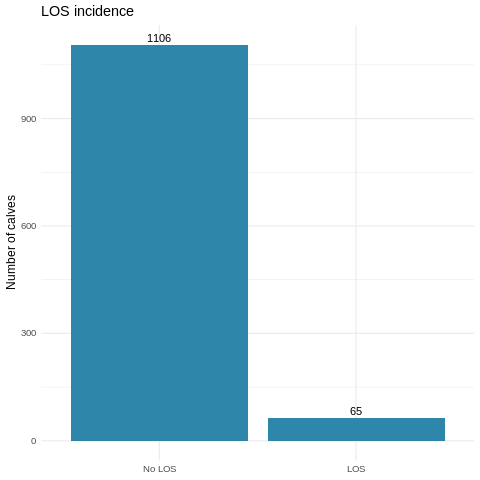

In [ ]:
%%R
library(scales)

inc_df <- lab_farm_summary %>%
  mutate(LOS_final = factor(LOS_final, levels=c(0,1), labels=c("No LOS", "LOS")))

ggplot(inc_df, aes(x = LOS_final)) +
  geom_bar(fill = "#2E86AB") + #to fill the colour blue
  geom_text(stat="count", aes(label=after_stat(count)), vjust=-0.3) + #-0.3 places the number above the bar graph
  labs(
    title = "LOS incidence",
    x = NULL, y = "Number of calves"
  ) +
  theme_minimal(base_size = 12)

##Pre-Model Prep

Cleaning and adding Different features before running the model

In [ ]:
%%R
str(lab_farm_data)
summary(lab_farm_data)

tibble [1,171 × 96] (S3: tbl_df/tbl/data.frame)
 $ calf_ID                                        : chr [1:1171] "1292" "1365" "1383" "1387" ...
 $ recipient_ID                                   : chr [1:1171] "24057" "24461" "24446" "24476" ...
 $ recipient_calving_date                         : Date[1:1171], format: "2023-06-06" "2023-10-15" ...
 $ dam_ID                                         : num [1:1171] 23719 23719 24222 6288 24548 ...
 $ caesarean_indicator                            : Factor w/ 1 level "TRUE": NA NA NA NA NA NA NA NA NA NA ...
 $ navel_indicator                                : logi [1:1171] NA NA NA NA NA NA ...
 $ caesarean_binary                               : num [1:1171] 0 0 0 0 0 0 0 0 0 0 ...
 $ navel_treatment_binary                         : num [1:1171] 0 0 0 0 0 0 0 0 0 0 ...
 $ LOS_positive                                   : num [1:1171] 0 0 0 0 0 0 0 0 0 0 ...
 $ calf_gender_remark                             : chr [1:1171] "M-ET" "M-ET" "MET" 

In [ ]:
%%R

 lab_farm_data <- lab_farm_data %>%
  mutate(
    LOS_final = factor(LOS_final, levels=c(0,1), labels=c("Healthy","LOS")), #converts 0/1 into Healthy and LOS
    is_pooled_batch = factor(ifelse(grepl("\n", dam_boviteq_number), "Yes", "No"))
  ) %>%

  select(-c(
    calf_ID, recipient_ID, donor_ID.x,
    sire_ID.x, dam_complete_name,
    dam_registration_number, sire_a_complete_name,
    embryo_lot, caesarean_indicator,
    navel_indicator, LOS_positive, LOS_remark_indicator,
    donor_level, follicles_1_4_mm, follicles_greater_than_15_mm
  )) %>% #removing unwanted coloumns

mutate(
    across(c(
      `0_to_2_layers_of_cumulus`, greater_than_or_equal_to_3_layers_of_cumulus,    #convert coloumns to numeric
      degenerated_oocytes, coasting_duration, total_aspirated_follicles,
      follicles_5_6_mm, follicles_7_10_mm, follicles_11_15_mm
    ), as.numeric),

    dam_birth_date = as.Date(dam_birth_date),
    dam_age_at_opu_months = as.numeric(stringr::str_extract(dam_age_at_opu, "\\d+")),    #convert coloumnns to date format
    embryo_age = as.numeric(as.character(embryo_age)),
    embryo_age = ifelse(embryo_age > 20, NA, embryo_age),

    embryo_grade = as.factor(embryo_grade),
    lab = as.factor(lab),
    sire_a_semen_type = as.factor(sire_a_semen_type),

    embryo_transfer_date = as.Date(embryo_transfer_date),
    recipient_bred_date = as.Date(recipient_bred_date),
    recipient_calving_date = as.Date(recipient_calving_date),
    recipient_birthdate = as.Date(recipient_birthdate)
  )

str(lab_farm_data)
summary(lab_farm_data)

tibble [1,171 × 83] (S3: tbl_df/tbl/data.frame)
 $ recipient_calving_date                         : Date[1:1171], format: "2023-06-06" "2023-10-15" ...
 $ dam_ID                                         : num [1:1171] 23719 23719 24222 6288 24548 ...
 $ caesarean_binary                               : num [1:1171] 0 0 0 0 0 0 0 0 0 0 ...
 $ navel_treatment_binary                         : num [1:1171] 0 0 0 0 0 0 0 0 0 0 ...
 $ calf_gender_remark                             : chr [1:1171] "M-ET" "M-ET" "MET" "MET" ...
 $ LOS_final                                      : Factor w/ 2 levels "Healthy","LOS": 1 1 1 1 1 1 1 1 1 1 ...
 $ ET_status                                      : chr [1:1171] "ET" "ET" "ET" "ET" ...
 $ recipient_bred_date                            : Date[1:1171], format: "2022-09-06" "2023-01-15" ...
 $ embryo_transfer_date                           : Date[1:1171], format: "2022-09-13" "2023-01-22" ...
 $ recipient_heat_date                            : chr [1:1171] "MO

In [ ]:
%%R
#features
#Embryo–recipient synchrony
lab_farm_data <- lab_farm_data %>%
  mutate(
    days_between_heat_and_transfer =
      as.numeric(embryo_transfer_date - recipient_bred_date),

    embryo_sync =
      embryo_age - days_between_heat_and_transfer,

    sync_abs = abs(embryo_sync),

    sync_category = case_when(
      sync_abs == 0 ~ "perfect",
      sync_abs == 1 ~ "moderate",
      sync_abs >= 2 ~ "poor",
      TRUE ~ NA_character_
    )
  )

#Recipient age before giving birth
lab_farm_data <- lab_farm_data %>%
  mutate(
    recipient_age_days =
      as.numeric(recipient_calving_date - recipient_birthdate),

    recipient_age_years = recipient_age_days / 365
  )

#Seasonal effect
lab_farm_data <- lab_farm_data %>%
  mutate(
    transfer_month = as.numeric(format(embryo_transfer_date, "%m")),
    season = case_when(
      transfer_month %in% c(12,1,2) ~ "winter",
      transfer_month %in% c(3,4,5) ~ "spring",
      transfer_month %in% c(6,7,8) ~ "summer",
      TRUE ~ "fall"
    )
  )

#Embryo quality ratios
lab_farm_data <- lab_farm_data %>%
  mutate(
    cleavage_rate = number_of_cleaved_embryos / total_structures_found,
    viability_rate = number_of_viable_embryos / total_structures_found,
    morula_rate = number_of_morulas / total_structures_found
  )

#Follicle distribution
lab_farm_data <- lab_farm_data %>%
  mutate(
    small_follicles = follicles_5_6_mm,
    large_follicles = follicles_11_15_mm,
    follicle_ratio = large_follicles / (small_follicles + 1) #follicle ratio
  )

#Oocyte Quality Ratio
lab_farm_data <- lab_farm_data %>%
  mutate(
    prop_good_cumulus =
      greater_than_or_equal_to_3_layers_of_cumulus / total_structures_found,

    prop_poor_cumulus =
      `0_to_2_layers_of_cumulus` / total_structures_found,

    cumulus_ratio =
      greater_than_or_equal_to_3_layers_of_cumulus /
      (`0_to_2_layers_of_cumulus` + 1)
  )

#Maturation to Fertilisation Time Ratio
lab_farm_data <- lab_farm_data %>%
  mutate(
    total_lab_time =
      in_vitro_maturation_duration +
      in_vitro_fertilisation_duration,

    maturation_to_fertilisation_ratio =
      in_vitro_maturation_duration /
      (in_vitro_fertilisation_duration + 1)
  )

  #efficiency
  lab_farm_data <- lab_farm_data %>%
  mutate(
    embryos_per_oocyte =
      number_of_viable_embryos / oocytes_in_maturation,

    cleavage_per_oocyte =
      number_of_cleaved_embryos / oocytes_in_maturation
  )

  #sire birth year
  lab_farm_data <- lab_farm_data %>%
  mutate(
    sire_birth_year = as.integer(format(as.Date(.data$sire_a_birth_date), "%Y"))
  )

  #embryo density
  lab_farm_data <- lab_farm_data %>%
  mutate(
    embryos_per_transfer = number_of_viable_embryos,
    embryo_density =
      number_of_viable_embryos / (days_between_heat_and_transfer + 1)
  )
#exclude FSH NA values (since it is showing up in the models)
lab_farm_data <- lab_farm_data %>%
  mutate(
    spo_program = dplyr::case_when(
      is.na(.data$spo_program) ~ "Unknown",
      trimws(as.character(.data$spo_program)) == "" ~ "Unknown",
      TRUE ~ as.character(.data$spo_program)
    ),
    spo_program = as.factor(.data$spo_program)
  )

lab_farm_data <- lab_farm_data %>%
  mutate(
    age_sync_interaction =
      recipient_age_years * sync_abs,

    embryo_age_vs_recipient_age =
      embryo_age / (recipient_age_years + 1)
  )

 #season sync
  lab_farm_data <- lab_farm_data %>%
  mutate(
    season_sync =
      interaction(season, sync_category)
  )

  #embryo grade
  lab_farm_data <- lab_farm_data %>%
  mutate(
    embryo_grade = as.character(.data$embryo_grade),
    embryo_grade = dplyr::if_else(
      .data$embryo_grade %in% c("1", "2"),
      .data$embryo_grade,
      NA_character_
    ),
    embryo_grade = factor(.data$embryo_grade, levels = c("1", "2"))
  )

#cleanup
lab_farm_data <- lab_farm_data %>%
  mutate(
    caesarean_binary = as.factor(caesarean_binary),
    navel_treatment_binary = as.factor(navel_treatment_binary),
    sync_category = as.factor(sync_category),
    season = as.factor(season),
    #convert transfer_month to a regular factor
    transfer_month = as.factor(as.character(transfer_month)),
     sire_age_missing = if_else(is.na(sire_a_age_at_semen_collection), 1, 0),
    sire_a_age_at_semen_collection = if_else(
      is.na(sire_a_age_at_semen_collection),
      median(sire_a_age_at_semen_collection, na.rm = TRUE),
      sire_a_age_at_semen_collection
  ))
  #creating a coloumn for gender and twins
  lab_farm_data <- lab_farm_data %>%
  mutate(
    calf_gender = case_when(
      grepl("^M|^m|/M", calf_gender_remark) ~ "Male",
      grepl("^F|^f|/F", calf_gender_remark) ~ "Female",
      TRUE ~ NA_character_
    ),

    #Keep twins separate because a Male Twin is different from a Male Single
    is_twin = if_else(
      grepl("/|TWIN|FF|MM", calf_gender_remark, ignore.case = TRUE), "Twin", "Single"
    )
  ) %>%
  mutate(
    calf_gender = as.factor(calf_gender),
    is_twin = as.factor(is_twin)
  )
#factor conversion
lab_farm_data$cumulus_expansion_post_maturation <-
  factor(lab_farm_data$cumulus_expansion_post_maturation)

str(lab_farm_data)
summary(lab_farm_data)

tibble [1,171 × 113] (S3: tbl_df/tbl/data.frame)
 $ recipient_calving_date                         : Date[1:1171], format: "2023-06-06" "2023-10-15" ...
 $ dam_ID                                         : num [1:1171] 23719 23719 24222 6288 24548 ...
 $ caesarean_binary                               : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 1 1 1 ...
 $ navel_treatment_binary                         : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 1 1 1 ...
 $ calf_gender_remark                             : chr [1:1171] "M-ET" "M-ET" "MET" "MET" ...
 $ LOS_final                                      : Factor w/ 2 levels "Healthy","LOS": 1 1 1 1 1 1 1 1 1 1 ...
 $ ET_status                                      : chr [1:1171] "ET" "ET" "ET" "ET" ...
 $ recipient_bred_date                            : Date[1:1171], format: "2022-09-06" "2023-01-15" ...
 $ embryo_transfer_date                           : Date[1:1171], format: "2022-09-13" "2023-01-22" ...
 $ recipient_heat_date               

In [ ]:
%%R
install.packages("h2o")
library(h2o)
h2o.init()

(as ‘lib’ is unspecified)







	‘/tmp/Rtmp6PBLPF/downloaded_packages’

----------------------------------------------------------------------

Your next step is to start H2O:
    > h2o.init()

For H2O package documentation, ask for help:
    > ??h2o

After starting H2O, you can use the Web UI at http://localhost:54321
For more information visit https://docs.h2o.ai

----------------------------------------------------------------------


Attaching package: ‘h2o’



    var



    day, hour, month, week, year



    hour, month, week, year



    cor, sd, var



    &&, %*%, %in%, ||, apply, as.factor, as.numeric, colnames,
    colnames<-, ifelse, is.character, is.factor, is.numeric, log,
    log10, log1p, log2, round, signif, trunc





H2O is not running yet, starting it now...

Note:  In case of errors look at the following log files:
    /tmp/Rtmp6PBLPF/filedd9edbf66e/h2o_UnknownUser_started_from_r.out
    /tmp/Rtmp6PBLPF/filedd9781e75c6/h2o_UnknownUser_started_from_r.err


Starting H2O JVM and connecting: ...... Connection successful!

R is connected to the H2O cluster: 
    H2O cluster uptime:         4 seconds 468 milliseconds 
    H2O cluster timezone:       Etc/UTC 
    H2O data parsing timezone:  UTC 
    H2O cluster version:        3.44.0.3 
    H2O cluster version age:    2 years, 6 months and 25 days 
    H2O cluster name:           H2O_started_from_R_root_urv678 
    H2O cluster total nodes:    1 
    H2O cluster total memory:   3.17 GB 
    H2O cluster total cores:    2 
    H2O cluster allowed cores:  2 
    H2O cluster healthy:        TRUE 
    H2O Connection ip:          localhost 
    H2O Connection port:        54321 
    H2O Connection proxy:       NA 
    H2O Internal Security:      FALSE 
    R 

Excluding varibales

In [ ]:
%%R

library(dplyr)

#EXCLUDED VARIABLES
exclude_vars <- c(
  "recipient_calving_date", "approx_recipient_calving_date",
  "donor_number", "laboratory", "collection_site",
  "dam's_owner_complete_name", "navel_treatment_binary", "caesarean_binary",
  "calf_gender_remark", "sire_a_semen_lot", "dam_boviteq_number", "dam_ID",
  "boviteq_lab_ID", "performed_by", "sire_a_registration_number", "sire_a_semen_code",
  "recipient_bred_date", "embryo_transfer_date", "opu_date", "insemination_date",
  "embryo_collection_date", "flush_date", "dam_birth_date", "recipient_birthdate",
  "total_structures_found", "cleavage_percent", "morulas_percent",
  "embryos_percent", "days_between_heat_and_transfer", "preg_open_binary",
  "dam's_owner_short_name", "recipient_age_days", "dam_age_at_opu",
  "total_aspirated_follicles", "small_follicles", "large_follicles",
  "follicles_5_6_mm", "follicles_7_10_mm", "follicles_11_15_mm",
  "oocytes_in_maturation", "0_to_2_layers_of_cumulus",
  "greater_than_or_equal_to_3_layers_of_cumulus", "degenerated_oocytes",
  "number_of_cleaved_embryos", "number_of_morulas", "number_of_viable_embryos",
  "good_quality_morulas", "poor_quality_morulas", "potentially_freezable_embryos",
  "total_discarded", "total_frozens",
  "viability_rate", "morula_rate", "predictions_of_viable_embryos",
  "prop_good_cumulus", "prop_poor_cumulus",
  "cleavage_rate", "transfer_day_of_week", "season_sync",
  "sire_a_age_at_semen_collection", "transfer_month",
  "sync_abs", "age_sync_interaction", "embryo_age_vs_recipient_age",
  "is_twin", "lab", "sire_a_birth_date",
  "prop_poor_quality", "dam_atq_number",
  "in_vitro_maturation_duration",
  "in_vitro_fertilisation_duration",
  "is_pooled_batch","donor_ID.y", "sire_ID.y","total_lab_time",
  "maturation_to_fertilisation_ratio", "sire_a_breed_code","lot_number",
  "recipient_heat_time","sire_age_missing","embryo_sync","embryo_density"
)

#master data creation (used for all models)
master_data <- lab_farm_data %>%
  dplyr::select(-any_of(exclude_vars)) %>%
  dplyr::select(where(~ mean(is.na(.)) < 0.30)) %>%
  dplyr::select(where(~ n_distinct(., na.rm = TRUE) > 1)) %>%
  dplyr::filter(!is.na(LOS_final))

#formatting
master_data$LOS_final <- as.character(master_data$LOS_final)
master_data$LOS_final[master_data$LOS_final != "LOS"] <- "Healthy"
master_data$LOS_final <- factor(master_data$LOS_final, levels = c("Healthy", "LOS"))

  glimpse(master_data)
  summary(master_data)

Rows: 1,171
Columns: 25
$ LOS_final                                       <fct> Healthy, Healthy, Heal…
$ recipient_heat_date                             <chr> "MON", "SAT", "THURS",…
$ embryo_age                                      <dbl> 7, 7, 7, 6, 6, 7, 6, 7…
$ embryo_grade                                    <fct> 1, 1, 1, 1, 1, 1, 1, 1…
$ recipient_cycle_date                            <dbl> 8, 8, 8, 8, 7, 8, 8, 8…
$ dam_starting_state                              <chr> "P4 Injected", "P4 Inj…
$ sire_a_semen_type                               <fct> Conventional, Conventi…
$ spo_program                                     <fct> P300F, 2.5 cc FSH x 6,…
$ coasting_duration                               <dbl> 43, 40, 40, 40, 40, 40…
$ in_vitro_maturation_time                        <dbl> 820, 642, 849, 849, 76…
$ cumulus_expansion_post_maturation               <fct> A, A, A, A, A, A, A, A…
$ heparin_concentration_in_fertilisation_droplets <dbl> 2.00, 3.00, 1.50, 1.50…
$ in_vitro_ferti

In [ ]:
%%R

output_dir <- "/content/drive/Shareddrives/Bovi-Analytics/B&B 2025 Spring semester"
if (!dir.exists(output_dir)) {
  dir.create(output_dir, recursive = TRUE)
}

write.csv(master_data, file.path(output_dir, "master_data.csv"), row.names = FALSE)

Model Training

##H2O Model

In [ ]:
%%R

library(h2o)
library(dplyr)

BALANCE_CLASSES <- TRUE #for imbalanced dataset
AML_SEED <- 123L
MAX_MODELS <- 40L #changed total number of models during re reuns

#70/15/15 train/valid/test split
set.seed(123)
idx_healthy <- which(master_data$LOS_final == "Healthy")
idx_los <- which(master_data$LOS_final == "LOS")
split_fn <- function(idx) {
  n <- length(idx)
  idx <- sample(idx)
  n_train <- floor(0.7 * n)
  n_valid <- floor(0.15 * n)

  list(
    train = idx[1:n_train],
    valid = idx[(n_train+1):(n_train+n_valid)],
    test  = idx[(n_train+n_valid+1):n]
  )
}

h <- split_fn(idx_healthy)
l <- split_fn(idx_los)

train_df <- master_data[c(h$train, l$train), ]
valid_df <- master_data[c(h$valid, l$valid), ]
test_df  <- master_data[c(h$test,  l$test), ]

#H2O
h2o.init(nthreads = -1, max_mem_size = "8G")

train_hf <- as.h2o(train_df)
valid_hf <- as.h2o(valid_df)
test_hf  <- as.h2o(test_df)

y <- "LOS_final"
x <- setdiff(colnames(train_hf), y)

train_hf[, y] <- as.factor(train_hf[, y])
valid_hf[, y] <- as.factor(valid_hf[, y])
test_hf[, y]  <- as.factor(test_hf[, y])

#autoML
aml <- h2o.automl(
  x = x,
  y = y,
  training_frame = train_hf,
  validation_frame = valid_hf,
  leaderboard_frame = valid_hf,
  max_models = MAX_MODELS,
  seed = AML_SEED,
  balance_classes = BALANCE_CLASSES,
  nfolds = 5, #best for cross validation
  sort_metric = "AUCPR",
  stopping_metric = "AUCPR" #better for class imbalance dataset
)

best_model <- aml@leader
print(aml@leaderboard)

 Connection successful!

R is connected to the H2O cluster: 
    H2O cluster uptime:         5 seconds 698 milliseconds 
    H2O cluster timezone:       Etc/UTC 
    H2O data parsing timezone:  UTC 
    H2O cluster version:        3.44.0.3 
    H2O cluster version age:    2 years, 6 months and 25 days 
    H2O cluster name:           H2O_started_from_R_root_urv678 
    H2O cluster total nodes:    1 
    H2O cluster total memory:   3.15 GB 
    H2O cluster total cores:    2 
    H2O cluster allowed cores:  2 
    H2O cluster healthy:        TRUE 
    H2O Connection ip:          localhost 
    H2O Connection port:        54321 
    H2O Connection proxy:       NA 
    H2O Internal Security:      FALSE 
    R Version:                  R version 4.6.0 (2026-04-24) 

  |======================================================================| 100%
  |======================================================================| 100%
  |=================================================================

Threshold and Confusion Matrix

In [ ]:
%%R

library(dplyr)
library(ggplot2)

#Test set predictions
pred_test <- h2o.predict(best_model, test_hf)

#Valid set predictions
pred_valid <- h2o.predict(best_model, valid_hf)

pred_df <- as.data.frame(pred_test)
test_df_r <- as.data.frame(test_hf)

#Add actual labels
pred_df$actual <- test_df_r$LOS_final #create new coloumn called actual and adds LOS/Healthy

#Probability of LOS class
pred_df$prob_LOS <- pred_df$LOS

#Test Set Performance
perf_test <- h2o.performance(best_model, newdata = test_hf)
cat("\nTEST RESULTS\n")
cat("AUC:", h2o.auc(perf_test), "\n")
cat("PR-AUC:", h2o.aucpr(perf_test), "\n")
cat("LogLoss:", h2o.logloss(perf_test), "\n")

#Validation set performance
perf_valid <- h2o.performance(best_model, newdata = valid_hf)
cat("\nVALIDATION PERFORMANCE\n")
cat("AUC:", h2o.auc(perf_valid), "\n")
cat("PR-AUC:", h2o.aucpr(perf_valid), "\n")
cat("LogLoss:", h2o.logloss(perf_valid), "\n")

#threshold selection (using validation data set)
thz <- as.data.frame(
  h2o.thresholds_and_metric_scores(perf_valid)
)

#high recall
target_recall <- 0.70 #have changed this during re-runs and picked best outcome

best_row <- thz %>%
  filter(tpr >= target_recall) %>%   #recall constraint
  arrange(desc(precision)) %>%       #best precision under constraint
  slice(1)

best_threshold <- best_row$threshold
cat("\nThreshold at recall ≥", target_recall, ":", best_threshold, "\n")

#best threshold
cat("\nBEST THRESHOLD METRICS\n")

#Print column names of best_row
print(colnames(best_row))

cols_to_show <- intersect(
  c(
    "threshold",
    "precision",
    "recall",
    "f1",
    "accuracy",
    "specificity",
    "absolute_mcc",
    "tns",
    "fns",
    "fps",
    "tps",
    "tpr",
    "fpr",
    "tnr",
    "fnr"
  ),
  colnames(best_row)
)

print(best_row[, cols_to_show])

#Confusion matrix on the test set
pred_class <- ifelse(
  pred_df$prob_LOS >= best_threshold,
  "LOS",
  "Healthy"
)
cat("\nCONFUSION MATRIX\n")
print(
  table(
    Predicted = pred_class,
    Actual = pred_df$actual
  )
)

  |======================================================================| 100%
  |======================================================================| 100%

TEST RESULTS
AUC: 0.7093087 
PR-AUC: 0.1191928 
LogLoss: 0.3014678 

VALIDATION PERFORMANCE
AUC: 0.7690236 
PR-AUC: 0.3226365 
LogLoss: 0.2119453 

Threshold at recall ≥ 0.7 : 0.00440488 

BEST THRESHOLD METRICS
 [1] "threshold"               "f1"                     
 [3] "f2"                      "f0point5"               
 [5] "accuracy"                "precision"              
 [7] "recall"                  "specificity"            
 [9] "absolute_mcc"            "min_per_class_accuracy" 
[11] "mean_per_class_accuracy" "tns"                    
[13] "fns"                     "fps"                    
[15] "tps"                     "tnr"                    
[17] "fnr"                     "fpr"                    
[19] "tpr"                     "idx"                    
   threshold  precision    recall    f1  accuracy specifi

##GBM


SELECTED GBM MODEL:
[1] "GBM_3_AutoML_1_20260715_202212"

GBM TEST PERFORMANCE:
AUC: 0.7093087 
PR-AUC: 0.1191928 
LogLoss: 0.3014678 

TOP 15 VARIABLE IMPORTANCE:
                                          variable relative_importance
1                              recipient_age_years           239.87677
2                                      spo_program           163.67821
3                      in_vitro_fertilisation_time           141.70876
4                                    cumulus_ratio           129.68198
5                                           season           118.10978
6                                prop_good_quality            83.66571
7                                    sync_category            82.40424
8                               embryos_per_oocyte            76.52213
9                             embryos_per_transfer            71.45367
10                             cleavage_per_oocyte            65.11967
11                        in_vitro_maturation_time    

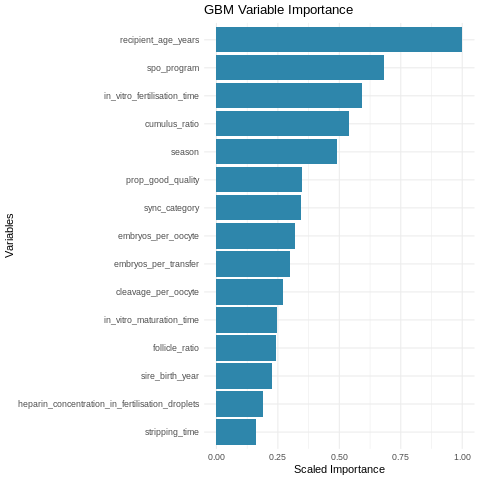

In [ ]:
%%R

library(h2o)
library(dplyr)
library(ggplot2)

#Get best GBM from AutoML leaderboard (by PR-AUC)
gbm_id <- as.data.frame(aml@leaderboard) %>%
  filter(grepl("GBM", model_id)) %>%
  arrange(desc(aucpr)) %>%
  slice(1) %>%
  pull(model_id)

gbm_model <- h2o.getModel(gbm_id)

cat("\nSELECTED GBM MODEL:\n")
print(gbm_id)

#test data performance
perf_gbm <- h2o.performance(gbm_model, newdata = test_hf) #model was evaluated on test data

cat("\nGBM TEST PERFORMANCE:\n")
cat("AUC:", h2o.auc(perf_gbm), "\n")
cat("PR-AUC:", h2o.aucpr(perf_gbm), "\n")
cat("LogLoss:", h2o.logloss(perf_gbm), "\n")

#VARIABLE IMPORTANCE
vi <- as.data.frame(h2o.varimp(gbm_model))
cat("\nTOP 15 VARIABLE IMPORTANCE:\n")
print(
  vi %>%
    select(
      variable,
      relative_importance,
      scaled_importance,
      percentage
    ) %>%
    slice(1:15)
)
#plot GBM
top_vi <- vi %>%
  slice(1:15)
ggplot(top_vi,
       aes(x = reorder(variable, scaled_importance),
           y = scaled_importance)) +
  geom_col(fill = "#2E86AB") +
  coord_flip() +
  theme_minimal() +
  labs(title = "GBM Variable Importance",
       x = "Variables",
       y = "Scaled Importance")

##GBM-SHAP


TOP VARIABLES FOR SHAP:
 [1] "recipient_age_years"         "spo_program"                
 [3] "in_vitro_fertilisation_time" "cumulus_ratio"              
 [5] "season"                      "prop_good_quality"          
 [7] "sync_category"               "embryos_per_oocyte"         
 [9] "embryos_per_transfer"        "cleavage_per_oocyte"        


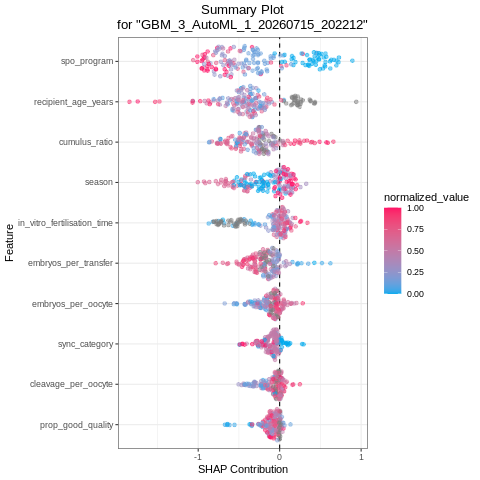

In [ ]:
%%R

#Top variables from GBM
vi <- as.data.frame(h2o.varimp(gbm_model))

top_vars <- head(vi$variable, 10)

cat("\nTOP VARIABLES FOR SHAP:\n")
print(top_vars)

#SHAP summary plot for top variables
h2o.shap_summary_plot(
  gbm_model,
  newdata = test_hf,
  columns = top_vars
)

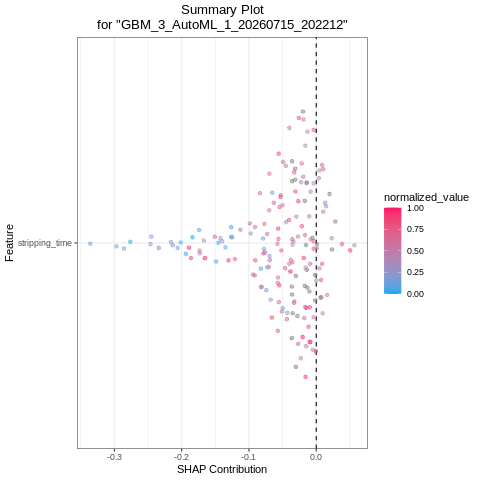

In [ ]:
%%R

#GBM Model - to test individual SHAP plotting over combined
lb <- as.data.frame(aml@leaderboard)

gbm_id <- lb %>%
  dplyr::filter(grepl("GBM", model_id)) %>%
  dplyr::slice(1) %>%
  dplyr::pull(model_id)

gbm_model <- h2o.getModel(gbm_id)

#Individual SHAP
h2o.shap_summary_plot(
  gbm_model,
  newdata = test_hf,
  columns = "stripping_time"
)

##XGBOOST


SELECTED XGBoost MODEL:
[1] "XGBoost_grid_1_AutoML_1_20260715_202212_model_10"

XGBOOST TEST PERFORMANCE:
AUC: 0.7177463 
PR-AUC: 0.3100958 
LogLoss: 0.2391678 

TOP 15 VARIABLE IMPORTANCE:
                                          variable relative_importance
1                              recipient_age_years           600.38531
2                                    cumulus_ratio           398.84955
3                      in_vitro_fertilisation_time           320.99966
4                              cleavage_per_oocyte           305.84311
5                            dam_age_at_opu_months           225.74564
6                                prop_good_quality           207.20575
7                                   stripping_time           174.61781
8  heparin_concentration_in_fertilisation_droplets           174.08438
9                             embryos_per_transfer           173.48344
10                              embryos_per_oocyte           170.63669
11                          

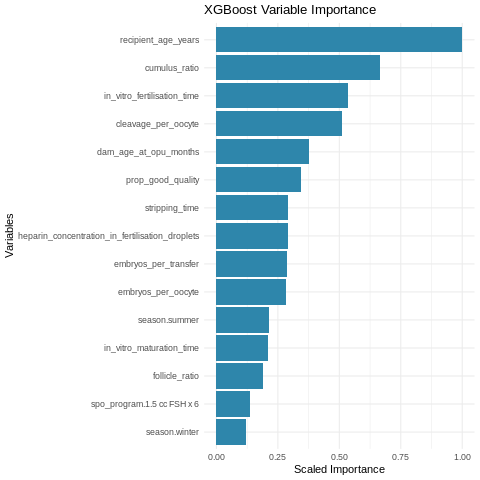

In [ ]:
%%R

library(h2o)
library(dplyr)
library(ggplot2)

#Get best xgboost from AutoML leaderboard (by PR-AUC)
xgb_id <- as.data.frame(aml@leaderboard) %>%
  filter(grepl("XGBoost", model_id)) %>%
  arrange(desc(aucpr)) %>%
  slice(1) %>%
  pull(model_id)

xgb_model <- h2o.getModel(xgb_id)

cat("\nSELECTED XGBoost MODEL:\n")
print(xgb_id)

#test data performance
perf_xgb <- h2o.performance(xgb_model, newdata = test_hf) #model was evaluated on test data

cat("\nXGBOOST TEST PERFORMANCE:\n")
cat("AUC:", h2o.auc(perf_xgb), "\n")
cat("PR-AUC:", h2o.aucpr(perf_xgb), "\n")
cat("LogLoss:", h2o.logloss(perf_xgb), "\n")

#VARIABLE IMPORTANCE
vi <- as.data.frame(h2o.varimp(xgb_model))
cat("\nTOP 15 VARIABLE IMPORTANCE:\n")
print(
  vi %>%
    select(
      variable,
      relative_importance,
      scaled_importance,
      percentage
    ) %>%
    slice(1:15)
)
#plot XGB
top_vi <- vi %>%
  slice(1:15)
ggplot(top_vi,
       aes(x = reorder(variable, scaled_importance),
           y = scaled_importance)) +
  geom_col(fill = "#2E86AB") +
  coord_flip() +
  theme_minimal() +
  labs(title = "XGBoost Variable Importance",
       x = "Variables",
       y = "Scaled Importance")

In [ ]:
%%R
#check SOV and season in the rest of the list to see if it's dummy variables
vi <- as.data.frame(h2o.varimp(xgb_model))

vi[grep("^season|^spo_program", vi$variable), ]

                     variable relative_importance scaled_importance
11              season.summer          127.269928       0.211980415
14 spo_program.1.5 cc FSH x 6           81.603683       0.135918853
15              season.winter           72.626930       0.120967200
20   spo_program.2 cc FSH x 6           34.267056       0.057075106
26                season.fall           17.763863       0.029587437
28              season.spring           16.343330       0.027221403
29        spo_program.Unknown           14.603735       0.024323938
30          spo_program.P300F            8.089988       0.013474660
31          spo_program.P240F            2.002428       0.003335238
     percentage
11 0.0343411752
14 0.0220190774
15 0.0195968850
20 0.0092462609
26 0.0047932134
28 0.0044099119
29 0.0039405178
30 0.0021829170
31 0.0005403141


##XGBoost-SHAP

In [ ]:
%%R

#Calculate SHAP contributions since SHAP summarises variables differently than XGB
shap_values <- as.data.frame(
  h2o.predict_contributions(
    xgb_model,
    test_hf
  )
)

#List all SHAP variables
names(shap_values)

  |======================================================================| 100%
 [1] "spo_program"                                    
 [2] "season"                                         
 [3] "sync_category"                                  
 [4] "cumulus_expansion_post_maturation"              
 [5] "embryo_grade"                                   
 [6] "sire_a_semen_type"                              
 [7] "embryo_age"                                     
 [8] "recipient_cycle_date"                           
 [9] "coasting_duration"                              
[10] "in_vitro_maturation_time"                       
[11] "heparin_concentration_in_fertilisation_droplets"
[12] "in_vitro_fertilisation_time"                    
[13] "stripping_time"                                 
[14] "prop_good_quality"                              
[15] "dam_age_at_opu_months"                          
[16] "recipient_age_years"                            
[17] "follicle_ratio"                   

In [ ]:
%%R

#calculate SHAP importance ranking
shap_importance <- data.frame(
  variable = names(shap_values),
  mean_abs_shap = sapply(
    shap_values,
    function(x) mean(abs(x))
  )
)

#Remove bias term
shap_importance <- shap_importance %>%
  filter(variable != "BiasTerm") %>%
  arrange(desc(mean_abs_shap))
print(shap_importance)

                                                                                       variable
recipient_age_years                                                         recipient_age_years
cumulus_ratio                                                                     cumulus_ratio
embryos_per_transfer                                                       embryos_per_transfer
in_vitro_fertilisation_time                                         in_vitro_fertilisation_time
cleavage_per_oocyte                                                         cleavage_per_oocyte
dam_age_at_opu_months                                                     dam_age_at_opu_months
spo_program                                                                         spo_program
embryos_per_oocyte                                                           embryos_per_oocyte
stripping_time                                                                   stripping_time
heparin_concentration_in_fertilisation_d

 [1] "recipient_age_years"                            
 [2] "cumulus_ratio"                                  
 [3] "embryos_per_transfer"                           
 [4] "in_vitro_fertilisation_time"                    
 [5] "cleavage_per_oocyte"                            
 [6] "dam_age_at_opu_months"                          
 [7] "spo_program"                                    
 [8] "embryos_per_oocyte"                             
 [9] "stripping_time"                                 
[10] "heparin_concentration_in_fertilisation_droplets"
[11] "season"                                         
[12] "in_vitro_maturation_time"                       
[13] "prop_good_quality"                              
[14] "sync_category"                                  
[15] "follicle_ratio"                                 


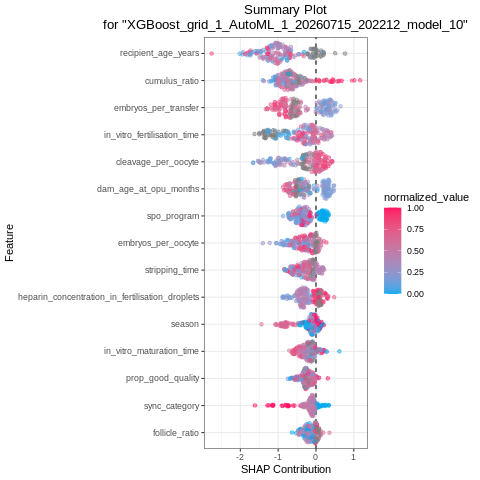

In [ ]:
%%R
#select top 15 variables according to SHAP
top_shap_vars <- shap_importance %>%
  slice_head(n = 15) %>%
  pull(variable)
print(top_shap_vars)

#SHAP plot
h2o.shap_summary_plot(
  xgb_model,
  newdata = test_hf,
  columns = top_shap_vars
)

In [ ]:
%%R
#export shap table
write.csv(shap_importance,
          "/content/drive/Shareddrives/Bovi-Analytics/B&B 2025 Spring semester/XGBoost_SHAP_importance.csv",
          row.names = FALSE)


TOP VARIABLES FOR SHAP:
 [1] "recipient_age_years"                            
 [2] "cumulus_ratio"                                  
 [3] "in_vitro_fertilisation_time"                    
 [4] "cleavage_per_oocyte"                            
 [5] "dam_age_at_opu_months"                          
 [6] "prop_good_quality"                              
 [7] "stripping_time"                                 
 [8] "heparin_concentration_in_fertilisation_droplets"
 [9] "embryos_per_transfer"                           
[10] "embryos_per_oocyte"                             
[11] "season.summer"                                  
[12] "in_vitro_maturation_time"                       
[13] "follicle_ratio"                                 
[14] "spo_program.1.5 cc FSH x 6"                     
[15] "season.winter"                                  


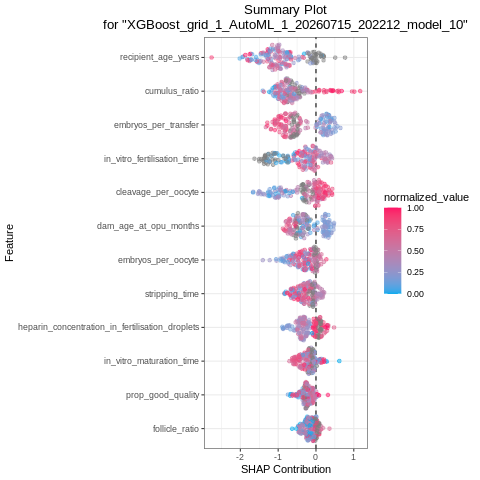

In [ ]:
%%R

#Top variables from GBM
vi <- as.data.frame(h2o.varimp(xgb_model))

top_vars <- head(vi$variable, 15)

cat("\nTOP VARIABLES FOR SHAP:\n")
print(top_vars)

#SHAP summary plot for top variables
h2o.shap_summary_plot(
  xgb_model,
  newdata = test_hf,
  columns = top_vars
)

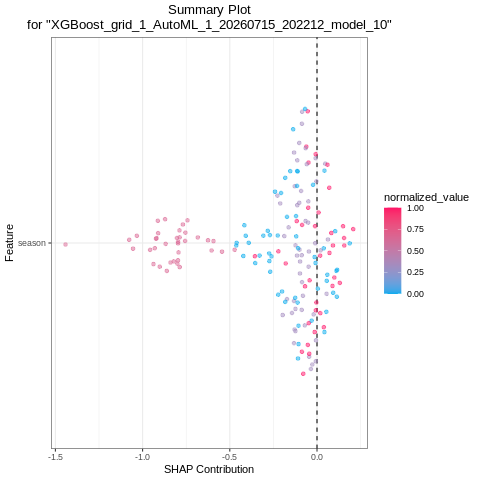

In [ ]:
%%R

#XGB Model - to test individual SHAP plotting over combined

#Individual SHAP
h2o.shap_summary_plot(
  xgb_model,
  newdata = test_hf,
  columns = "season"
)

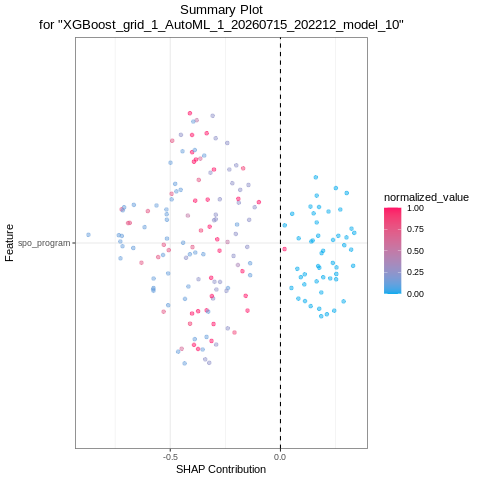

In [ ]:
%%R
h2o.shap_summary_plot(
  xgb_model,
  newdata = test_hf,
  columns = "spo_program"
)

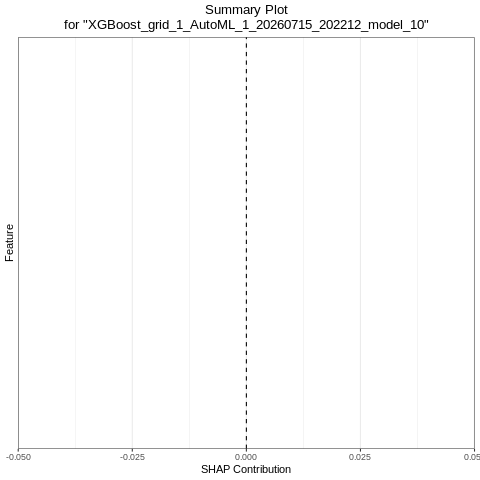

In [ ]:
%%R


#Individual SHAP
h2o.shap_summary_plot(
  xgb_model,
  newdata = test_hf,
  columns = "season.summer"
)

In [ ]:
%%R
h2o.predict_contributions(
  xgb_model,
  test_hf
)

  |======================================================================| 100%
  spo_program       season sync_category cumulus_expansion_post_maturation
1 -0.20047981  0.054930314   -0.13807049                                 0
2  0.32235605  0.004816771   -1.61337423                                 0
3  0.07652318  0.060300402   -0.06733818                                 0
4 -0.55471611 -0.005755469    0.05011692                                 0
5 -0.47772253 -0.408735871   -0.09426520                                 0
6 -0.14531650 -0.106123604    0.16275296                                 0
  embryo_grade sire_a_semen_type   embryo_age recipient_cycle_date
1 -0.048140235      -0.168110251 -0.034383375          -0.09007800
2 -0.010841612       0.011754822 -0.004143462          -0.05670733
3 -0.100296065      -0.307249337 -0.009929070          -0.04565523
4  0.007493723      -0.298457175 -0.060369559          -0.03043325
5 -0.017992772      -0.002188243 -0.033126432          -0.02

In [ ]:
%%R

library(ggplot2)
#box plot for categorical variables
ggplot(shap_values, aes(x = season_cat, y = season)) +
  geom_boxplot(fill = "skyblue") +
  theme_bw() +
  labs(
    x = "Season",
    y = "SHAP contribution of season"
  )

Error in `geom_boxplot()`:
! Problem while computing aesthetics.
ℹ Error occurred in the 1st layer.
Caused by error:
! object 'season_cat' not found
Run `rlang::last_trace()` to see where the error occurred.


RRuntimeError: Error in geom_boxplot(fill = "skyblue") : 
ℹ Error occurred in the 1st layer.
Caused by error:
! object 'season_cat' not found


##LASSO & Firth Logistic Regression

In [ ]:
%%R

if (!require("brglm2")) {
    install.packages("brglm2", repos = "http://cran.us.r-project.org")
    library(brglm2)
}

In [ ]:
%%R

library(broom)
library(pROC)
library(PRROC)
library(logistf)

#Combine train & valid test sets
combined_train_hf <- h2o.rbind(train_hf, valid_hf)

#convert to data frames
train_df <- as.data.frame(combined_train_hf) %>%
  mutate(
    LOS_num = ifelse(LOS_final == "LOS", 1, 0)
  ) %>%
  na.omit()

test_df <- as.data.frame(test_hf) %>%
  mutate(
    LOS_num = ifelse(LOS_final == "LOS", 1, 0)
  ) %>%
  na.omit()

#LASSO on train dataset
x_train <- model.matrix(
  LOS_num ~ . - LOS_final,
  data = train_df
)[, -1]
y_train <- train_df$LOS_num
set.seed(123)
cv_lasso <- cv.glmnet(
  x_train,
  y_train,
  family = "binomial",
  alpha = 1,
  type.measure = "auc"
)

lasso_model <- glmnet(
  x_train,
  y_train,
  family = "binomial",
  alpha = 1,
  lambda = cv_lasso$lambda.min
)

#Variables selected by LASSO
coef_mat <- as.matrix(coef(lasso_model))
selected_vars <- rownames(coef_mat)[coef_mat[,1] != 0]
selected_vars <- setdiff(
  selected_vars,
  "(Intercept)"
)
cat("\nSELECTED VARIABLES:\n")
print(selected_vars)

#Firth on train dataset
x_train_df <- as.data.frame(x_train)
selected_vars <- intersect(
  selected_vars,
  colnames(x_train_df)
)
train_firth <- cbind(
  LOS_num = y_train,
  x_train_df[, selected_vars, drop = FALSE]
)

#Firth Logistic Regression
firth_model <- logistf(
  LOS_num ~ .,
  data = train_firth
)
#Model Summary
cat("\nFIRTH LOGISTIC REGRESSION RESULTS:\n")
print(summary(firth_model))

#Odds Ratio + CI + p-values
results <- data.frame(
  Variable = names(firth_model$coefficients),
  OR = exp(firth_model$coefficients),
  Lower_CI = exp(firth_model$ci.lower),
  Upper_CI = exp(firth_model$ci.upper),
  P_value = firth_model$prob
)
print(results)

#Test set for model evaluation
x_test <- model.matrix(
  LOS_num ~ . - LOS_final,
  data = test_df
)[, -1]
x_test_df <- as.data.frame(x_test)

selected_vars_test <- intersect(
  selected_vars,
  colnames(x_test_df)
)
test_firth <- x_test_df[, selected_vars_test, drop = FALSE]

#identify and remove non-complete rows (logistf cannot handle missing data)
complete_idx <- complete.cases(test_firth) #identify complete rows
test_firth <- test_firth[complete_idx, ] #remove missing rows
y_test <- test_df$LOS_num[complete_idx]

#Test prediction
pred <- predict(
  firth_model,
  newdata = test_firth,
  type = "response"
)
#ROC-AUC on test data
roc_obj <- pROC::roc(
  response = as.numeric(y_test),
  predictor = as.numeric(pred),
  quiet = TRUE
)

cat("\nTEST AUC:", as.numeric(pROC::auc(roc_obj)), "\n")

#PR-AUC on test data
pr_obj <- pr.curve(
  scores.class0 = pred[y_test == 1],
  scores.class1 = pred[y_test == 0],
  curve = TRUE
)
cat("TEST PR-AUC:", pr_obj$auc.integral, "\n")

#ROC-AUC curve
plot(
  roc_obj,
  main = "Firth Logistic Regression ROC Curve",
  col = "darkblue",
  lwd = 2
)

#PR-AUC curve
plot(
  pr_obj,
  main = "Firth Logistic Regression Precision-Recall Curve"
)

#CALIBRATION PLOT
cal_df <- data.frame(
  pred = pred,
  obs = y_test
)
ggplot(cal_df, aes(x = pred, y = obs)) +
  geom_smooth(method = "loess") +
  theme_minimal() +
  labs(
    title = "Calibration Plot (Firth Logistic Regression)",
    x = "Predicted Probability",
    y = "Observed Outcome"
  )

#Forest plot prep
plot_df <- results %>%
  filter(Variable != "(Intercept)") %>%
  mutate(
    log_estimate = log(OR),
    Lower_CI = pmax(Lower_CI, 0.001),
    Upper_CI = pmin(Upper_CI, 100)
  ) %>%
  arrange(log_estimate) %>%
  mutate(
    Variable = factor(
      Variable,
      levels = Variable
    )
  )

#Firth Forest Plot
ggplot(
  plot_df,
  aes(
    x = Variable,
    y = OR,
    color = OR > 1
  )
) +
  geom_hline(
    yintercept = 1,
    linetype = "dashed",
    linewidth = 0.6
  ) +
  geom_pointrange(
    aes(
      ymin = Lower_CI,
      ymax = Upper_CI
    ),
    size = 0.6,
    fatten = 2
  ) +
  coord_flip() +
  scale_y_log10(
    limits = c(0.01, 100),
    breaks = c(0.01, 0.1, 1, 10, 100)
  ) +
  scale_color_manual(
    values = c(
      "TRUE" = "darkred",
      "FALSE" = "steelblue"
    ),
    labels = c(
      "Protective",
      "Risk factor"
    )
  ) +

  labs(
    title = "Firth Logistic Regression",
    x = "Variables",
    y = "Odds Ratio (log scale)",
    color = "Effect direction"
  ) +

  theme_minimal(base_size = 13) +
  theme(
    panel.grid.major.y = element_blank(),
    legend.position = "top",
    axis.text.y = element_text(size = 10)
  )

##Decision Tree - CART

In [ ]:
%%R

library(dplyr)
library(rpart)
library(rpart.plot)

#Combine train & valid test sets
tree_data <- bind_rows(train_df, valid_df)

#Data prep
sel <- setdiff(names(tree_data), c("LOS_num", "LOS_final"))
tree_data <- tree_data %>%
  mutate(LOS_num = ifelse(LOS_final == "LOS", 1, 0))
orig_vars <- intersect(sel, names(tree_data))
tree_train <- tree_data %>%
  dplyr::select(all_of(orig_vars), LOS_num) %>%
  mutate(
    LOS_factor = factor(
      LOS_num,
      levels = c(0, 1),
      labels = c("Healthy", "LOS")
    )
  )

#Weight due to imbalance dataset
tree_weights <- ifelse(tree_train$LOS_factor == "LOS", 5, 1)

tree_plot_data <- tree_train %>%
  rename(
    Cleavage = cleavage_per_oocyte,
    Cumulus = cumulus_ratio,
    Follicles = follicle_ratio,
    Heparin = heparin_concentration_in_fertilisation_droplets,
    IVM_Time = in_vitro_maturation_time,
    Heat = recipient_heat_date,
    Season = season,
    SPO = spo_program,
    Strip_Time = stripping_time
  )

#Decision tree plot
set.seed(123)
tree_fit <- rpart(
  LOS_factor ~ .,
  data = tree_plot_data %>% dplyr::select(-LOS_num),
  weights = tree_weights,
  method = "class",
  control = rpart.control(
    cp = 0.02,
    minsplit = 20,
    minbucket = 10,
    maxdepth = 5
  )
)

#Model summary
printcp(tree_fit)

#Pruning
cp_tab <- tree_fit$cptable
best_cp <- cp_tab[which.min(cp_tab["xerror"]), "CP"]
cat("\nChosen CP:", best_cp, " ")
tree_pruned <- prune(tree_fit, cp = best_cp)

#Plot tree
options(repr.plot.width = 24, repr.plot.height = 14)
rpart.plot(
  tree_pruned,
  type = 2,
  extra = 104,
  box.palette = list("#E0F2F1", "#FFECB3", "#FFCCBC"),
  shadow.col = 0,
  cex = 0.8,
  tweak = 1.1,
  gap = 2.5,
  ygap = 6,
  nn = TRUE,
  yesno = 2,
  fallen.leaves = TRUE,
  faclen = 0,
  main = "Pruned Decision Tree for LOS"
)